# [IAPR][iapr]: Final project - Chocolate Recognition


**Moodle group ID:** *64*  
**Kaggle challenge:** *Classic*   
**Kaggle team name (exact):** "*Team Nah!*"  

**Author 1 (sciper):** Andrew Brown (370751)  
**Author 2 (sciper):** Nour Lachat (302397)   
**Author 3 (sciper):** Henry Farrell (402247) 

**Due date:** 21.05.2025 (11:59 pm)


## Key Submission Guidelines:
- **Before submitting your notebook, <span style="color:red;">rerun</span> it from scratch!** Go to: `Kernel` > `Restart & Run All`
- **Only groups of three will be accepted**, except in exceptional circumstances.


[iapr]: https://github.com/LTS5/iapr2025

---

> Your comments  
> ...

In [142]:
import src.lab1 as lab1 
import src.lab_01_utils as lab1utils
import src.lab2 as lab2
import src.lab_02_utils as lab2utils
import src.lab3 as lab3
import src.lab_03_utils as lab3utils
import src.preprocessing as pre
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import MiniBatchKMeans
from skimage.morphology import remove_small_objects, remove_small_holes, closing, disk, opening
from skimage.transform import rotate, resize
from sklearn.metrics.pairwise import euclidean_distances
from skimage.measure import regionprops
import cv2
from typing import Literal, Callable
import math
from scipy.ndimage import rotate
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from collections import Counter, defaultdict

##### Load Datasets #####


In [143]:
# Load the Datasets
references_path = "../data/dataset_project_iapr2025/references"
reference_images_raw, reference_labels, reference_dict = pre.load_reference_images(references_path)


train_path = "../data/dataset_project_iapr2025/train"
train_images_raw, train_labels, train_dict = pre.load_train_images(train_path)

In [144]:
N_train = 20 # Number of training images to train on

In [145]:
# Print Shape of Images
print(f"Reference images shape: {reference_images_raw[0].shape}")
print(f"Train images shape: {train_images_raw[0].shape}")

Reference images shape: (4000, 6000, 3)
Train images shape: (4000, 6000, 3)


##### Downsample Images to 400 x 600 pixels #####

In [146]:
reference_images = reference_images_raw.copy()
train_images = train_images_raw.copy()

# Downsample the images and update the reference_images list and dictionary
for i, imgs in enumerate(reference_images):
    # Downsample the image using grid method
    downsampled_grid = pre.downsample_image(
        imgs,
        method="grid",
        target_height=400,
        target_width=600  # Only one dimension needs specification
    )

    # Update the reference_images list with the downsampled images
    reference_images[i] = downsampled_grid
    reference_dict[reference_labels[i]] = downsampled_grid


# Do the same with the train images
for i, imgs in enumerate(train_images):
    # Downsample the image using grid method
    downsampled_grid = pre.downsample_image(
        imgs,
        method="grid",
        target_height=400,
        target_width=600  # Only one dimension needs specification
    )

    # Update the reference_images list with the downsampled images
    train_images[i] = downsampled_grid
    train_dict[train_labels[i]] = downsampled_grid


In [147]:
# Print New Image Shape vs Old Image Shape
print(f"Old Image Shape: {train_images_raw[0].shape}")
print(f"New Image Shape: {train_images[0].shape}")


Old Image Shape: (4000, 6000, 3)
New Image Shape: (400, 600, 3)


In [148]:
def extract_from_dictionary(dictionary, labels, keys: list) -> list:
    """
    Extracts values from a dictionary based on a list of keys.
    
    Args:
        dictionary: The input dictionary
        labels: List of labels to extract values from
        keys: List of keys to extract values for
    
    Returns:
        List of extracted values
    """
    extracted_values = []  # Initialize an empty list to store results
    for label in labels:
        if label in dictionary:
            dict_entry = dictionary[label]
            for key in keys:
                if key in dict_entry:
                    extracted_values.append(dict_entry[key])
                else:
                    extracted_values.append(None)
        else:
            extracted_values.append(None)
    return list(np.squeeze(np.array(extracted_values)))

##### Show Reference Chocolates #####

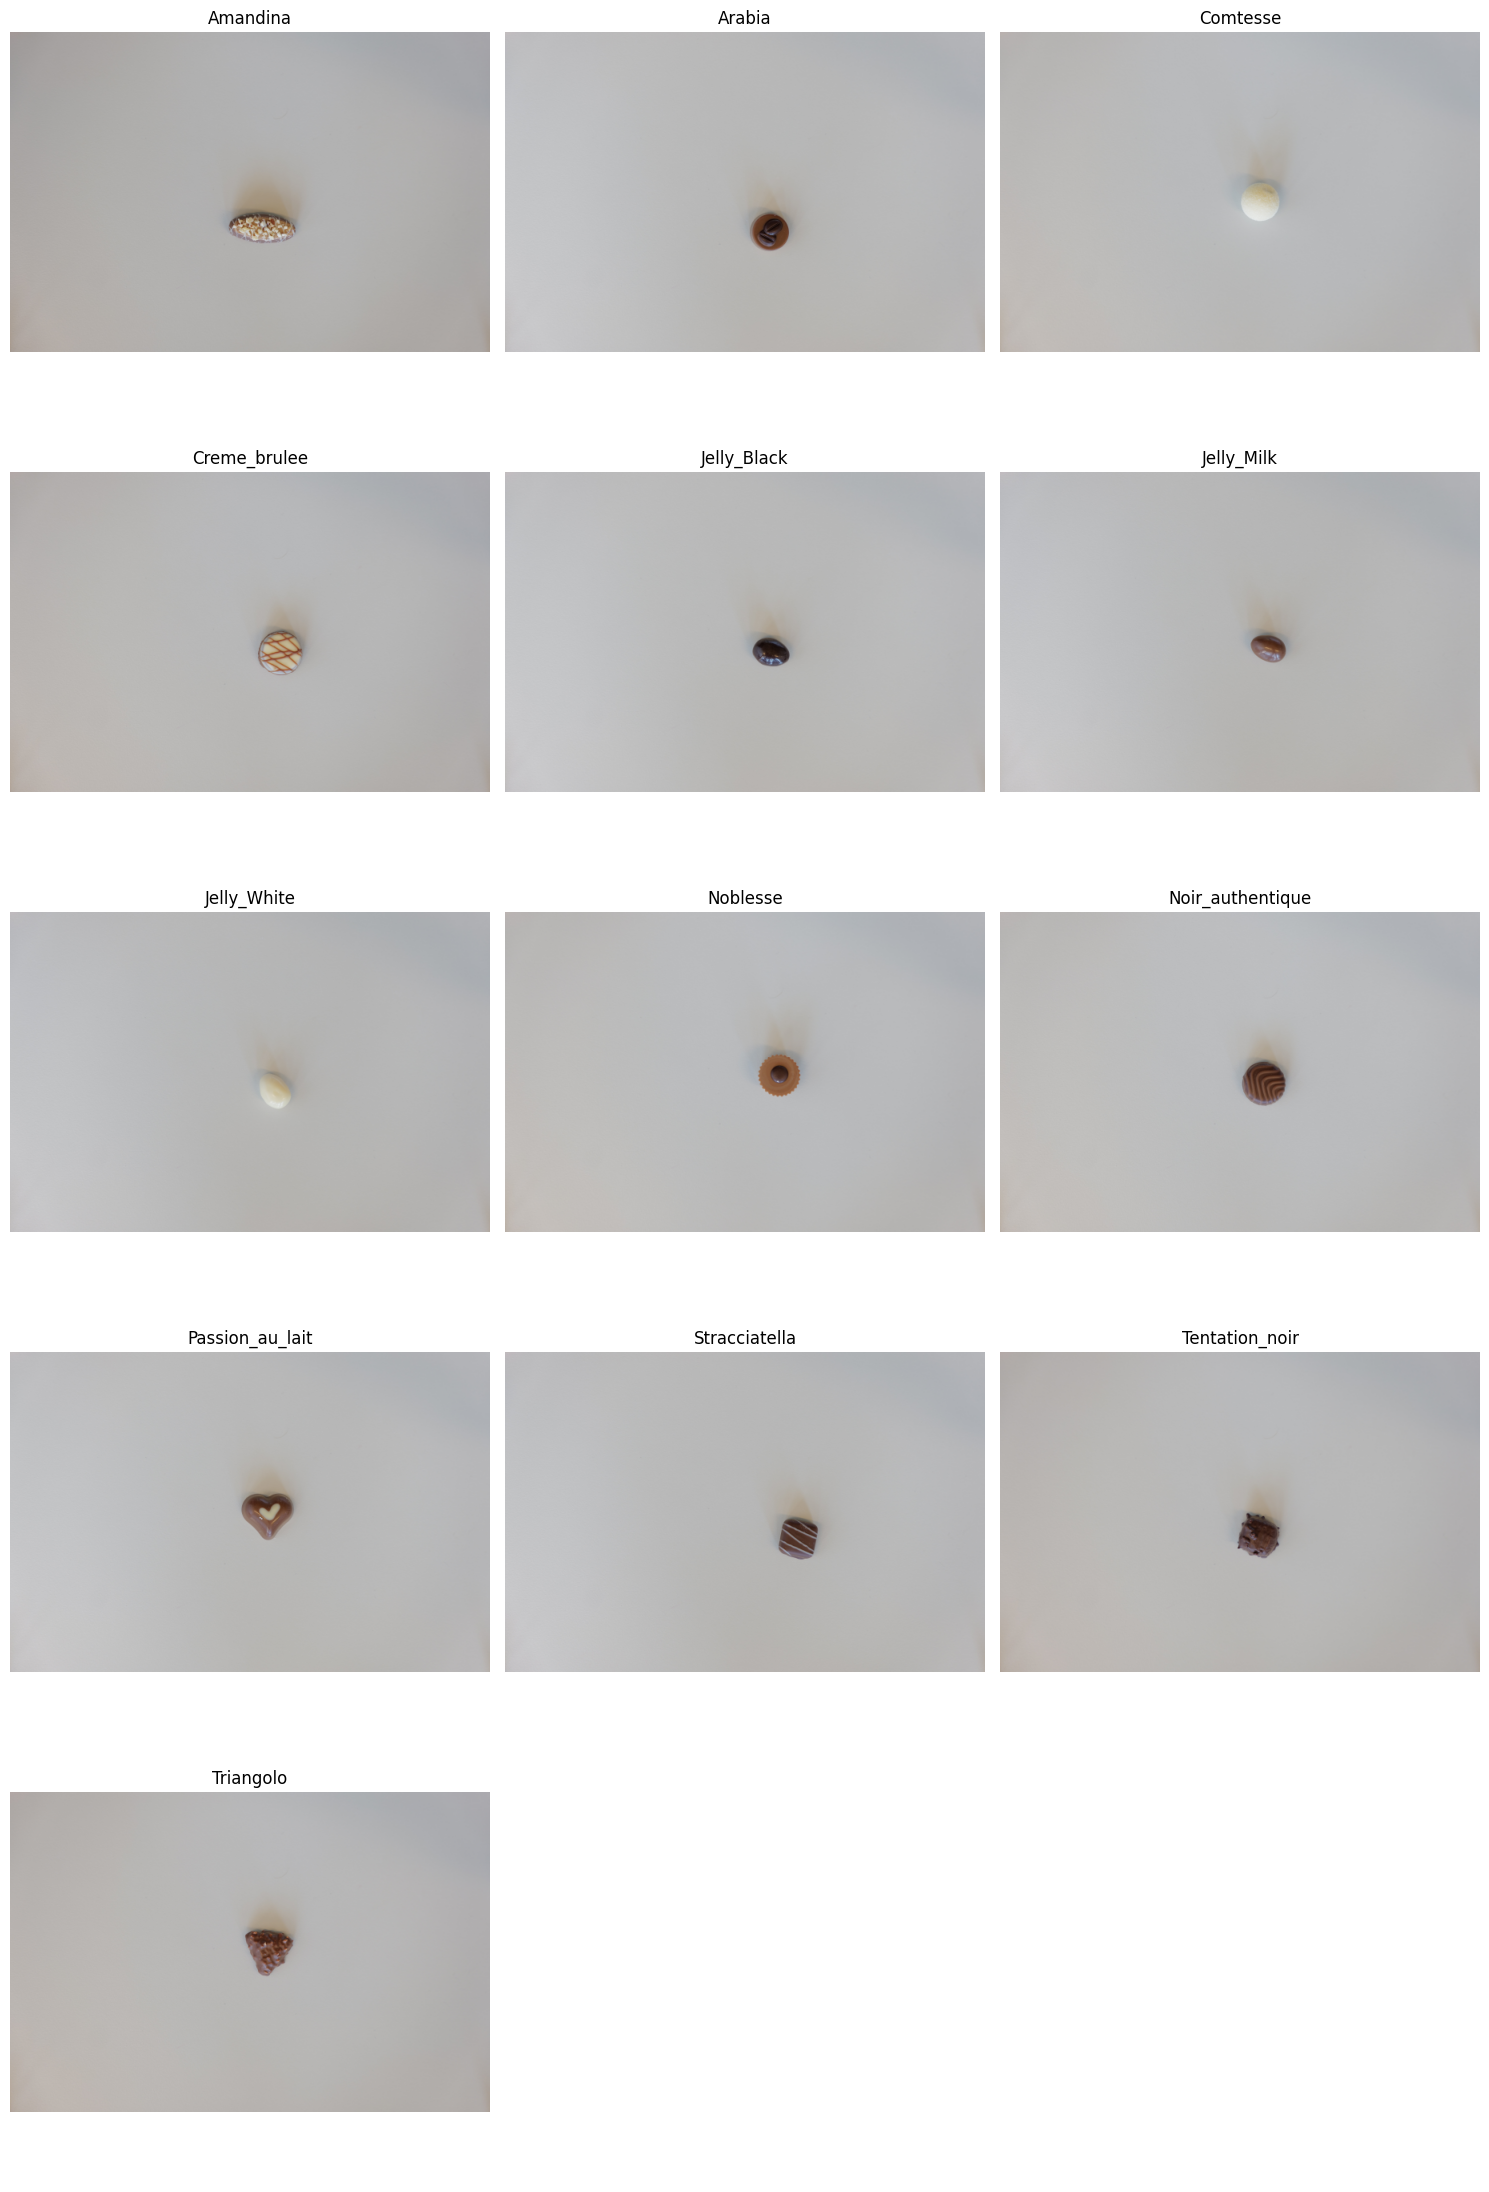

In [149]:
pre.plot_reference_images(reference_images, reference_labels)

## Section 1: Pre-Processing and Background Removal For Reference Images
The goal here is to take every image and separate the background from the foreground. This makes it easier to process, find contours, shape features, etc.

#### PREPROCESS THE REFERENCE IMAGES ####
- Augment Image
- Extract Image RGB and HSV Data
- Convert To Greyscale
- Convert to Binary Edges with Canny Edge Detection
- Apply Opening, Closing, Remove Holes, and Remove Objects

Results in Image with Chocolates as Binary Blobs

### Justification

#### Augment Image  
Each reference image is rotated (90°, 180°, 270°) to simulate different orientations. This improves the model’s ability to generalize across chocolates that appear at various angles.

#### Extract RGB and HSV Data  
Color information is extracted and stored in both RGB and HSV formats for later use in classification. Keeping both formats allows flexibility when analyzing color characteristics.

#### Isolate Chocolates as Binary Blobs  
To cleanly segment the chocolate, the image is converted to greyscale, followed by Canny edge detection to extract its outline. Morphological operations (opening, closing, hole filling, and small object removal) are then applied to produce a solid, noise-free binary mask.

This approach was chosen over thresholding or region growing because chocolates often have significant internal color and lighting variation, making those methods unreliable. However, since reference images always contain a single chocolate on a simple white background, edge detection is particularly effective and reliable here. The result is a clean binary blob representing the chocolate, suitable for extracting shape features.


In [150]:
# Canny Edge Detection Params
t_lower = 40
t_upper = 85 
aperture_size = 3 
L2Gradient = False

#Morphology Params
kernel_size=12
min_area_th=1
min_obj_size=100
connect=1

In [151]:
def augment_image(img):
    """Generate rotated versions with proper cropping"""
    augmented = []
    for angle in [90, 180, 270]:
        # Rotate and crop to remove black borders
        rotated = rotate(img, angle, reshape=True)
        h, w = img.shape[:2]
        if angle == 90:
            # For 90° rotation, crop to centered square
            crop_size = min(h, w)
            center = rotated.shape[0]//2, rotated.shape[1]//2
            cropped = rotated[center[0]-crop_size//2:center[0]+crop_size//2,
                             center[1]-crop_size//2:center[1]+crop_size//2]
        else:
            # For 180° rotation, maintain original dimensions
            cropped = rotated[:h, :w]
        augmented.append(cropped)
    return augmented

# Make the reference dictionary a dictionary of dictionaries with initialized values
reference_dict = {label: {"image": img} for label, img in zip(reference_labels, reference_images)}

aug = {}
for i, dict in enumerate(reference_dict.values()):
    # Extract reference image
    img = dict["image"]
    label = list(reference_dict.keys())[i]
    
    # Apply Augmentation
    aug_imgs = augment_image(img)
    rotations = [90, 180, 270]
    
    # Store augmentation
    for j, (aug_img, angle) in enumerate(zip(aug_imgs, rotations)):
        version_key = f"{label}_v{j}"
        aug[version_key] = {
            "original_label": label,
            "is_augmented": True,
            "rotation": angle,
            "image": aug_img
        }

    # Add new labels to reference_labels
    dict['original_label'] = label
    dict['is_augmented'] = False
    dict['rotation'] = 0

# Add augmented images to the reference dictionary
for key, value in aug.items():
    reference_dict[key] = value

# Make list of augmented labels and original labels
augmented_labels = list(reference_dict.keys())
# Verification
print(f"Total processed: {len(reference_dict)} (should be 13 originals + 13 * N augmentations)")
print("Sample breakdown:")
for label in set(reference_labels[:13]):
    versions = [k for k in reference_dict.keys() if k.startswith(label)]
    print(f"{label}: {len(versions)} versions")

# Visualize results for first 3 chocolates
# plt.figure(figsize=(15, 12))
# for choc_idx in range(3):  # First 3 chocolates
#     label = reference_labels[choc_idx]
#     versions = [k for k in all_processed_images if k.startswith(label)]
    
#     for ver_idx, ver in enumerate(versions[:3]):  # Original + 2 augmented
#         plt_idx = choc_idx*3 + ver_idx + 1
#         plt.subplot(3, 3, plt_idx)
#         plt.imshow(reference_dict[ver]["canny"], cmap='gray')
#         title = f"{label}\n"
#         title += "Original" if ver_idx == 0 else f"Rotated {reference_dict[ver]['rotation']}°"
#         plt.title(title)
#         plt.axis('off')

# plt.tight_layout()
# plt.show()


Total processed: 52 (should be 13 originals + 13 * N augmentations)
Sample breakdown:
Noir_authentique: 4 versions
Creme_brulee: 4 versions
Amandina: 4 versions
Jelly_White: 4 versions
Passion_au_lait: 4 versions
Noblesse: 4 versions
Jelly_Milk: 4 versions
Arabia: 4 versions
Comtesse: 4 versions
Triangolo: 4 versions
Tentation_noir: 4 versions
Jelly_Black: 4 versions
Stracciatella: 4 versions


In [152]:
### PREPROCESS REFERENCE IMAGES ###

# Start by extracting the RGB data from all the images
N = len(reference_dict)

for i, dict in enumerate(reference_dict.values()):
    label = dict["original_label"]
    img = dict["image"]
    # Extract the RGB channels
    R, G, B = lab1.extract_rgb_channels(img)
    H, S, V = lab1.extract_hsv_channels(img)
    
    # Update the dictionary to include the RGB and HSV channels
    dict["R"] = R
    dict["G"] = G
    dict["B"] = B
    dict["H"] = H
    dict["S"] = S
    dict["V"] = V
    
    # Apply the HSV thresholding
    img_grey = pre.RGB2greyscale(img)
    dict["grey"] = img_grey

    # Apply the Canny edge detection
    img_canny = cv2.Canny(img, t_lower, t_upper, apertureSize=aperture_size, L2gradient=L2Gradient)
    dict["canny"] = img_canny

    # Apply the morphology
    img_morph = lab1.apply_morphology(img_canny, kernel_size=kernel_size, min_area_th=min_area_th, min_obj_size=min_obj_size, connect=connect)
    dict["canny_morph"] = img_morph


c:\Users\sunde\Desktop\Local_Repos\ImageAnalysisAndPatternRecognitionGroupWork\project\src\lab1.py:275: UserWarning: Any labeled images will be returned as a boolean array. Did you mean to use a boolean array?
  img_morph = remove_small_holes(img_morph, area_threshold=min_area_th, connectivity=connect, out=None)


##### Create Bounding Boxes Around all of the Blobs for Extraction #####

In [153]:
### Find a single bounding box surrouning all contours in each reference image with the contours aroud the canny ###

def find_bounding_box(image: np.ndarray, contours: list) -> tuple[int, int, int, int]:
    """
    Find a single bounding box surrounding all contours in the image.

    
    Args:
        image: Input image (H, W, 3)
        contours: List of contours found in the image

    Returns:
        x_min, y_min, x_max, y_max: Coordinates of the bounding box
    """
    # Initialize min and max coordinates
    x_min = image.shape[1]
    y_min = image.shape[0]
    x_max = 0
    y_max = 0

    for contour in contours:
        # Get the bounding box for each contour
        x, y, w, h = cv2.boundingRect(contour)
        
        # Update min and max coordinates
        x_min = min(x_min, x)
        y_min = min(y_min, y)
        x_max = max(x_max, x + w)
        y_max = max(y_max, y + h)
    
    return x_min, y_min, x_max, y_max

# First pass: Find individual bounding boxes and determine max dimensions
bounding_boxes = []
max_width = 0
max_height = 0

for k, dict in enumerate(reference_dict.values()):
    # Extract the canny image
    img = dict["canny"]
    
    # Find contours
    contours, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Find bounding box around all contours
    x_min, y_min, x_max, y_max = find_bounding_box(img, contours)

    # Store bounding box
    bounding_boxes.append((x_min, y_min, x_max, y_max))

    # Update max width and height
    padding = 3
    width = x_max - x_min
    height = y_max - y_min
    max_width = max(max_width, width) + padding
    max_height = max(max_height, height) + padding

cropped_refrence_images = []
# Second pass: Re-extract bounding boxes using uniform size
for k, dict in enumerate(reference_dict.values()):
    og_img = dict["image"]
    img = dict["canny"]
    x_min, y_min, x_max, y_max = bounding_boxes[k]

    # Centered bounding box with uniform size
    center_x = (x_min + x_max) // 2
    center_y = (y_min + y_max) // 2

    new_x_min = max(center_x - max_width // 2, 0)
    new_y_min = max(center_y - max_height // 2, 0)
    new_x_max = min(new_x_min + max_width, og_img.shape[1])
    new_y_max = min(new_y_min + max_height, og_img.shape[0])

    # Save bounding box info
    dict["contour_bounding_box"] = (new_x_min, new_y_min, new_x_max, new_y_max)

    # Extract and save cropped image
    bbox_image = og_img[new_y_min:new_y_max, new_x_min:new_x_max]
    dict["bbox_image"] = bbox_image

    # Optional: draw rectangle on image
    img_with_box = img.copy()
    cv2.rectangle(img_with_box, (new_x_min, new_y_min), (new_x_max, new_y_max), (255, 0, 0), 2)
    dict["image_with_box"] = img_with_box
    cropped_refrence_images.append(bbox_image)

    # print(f"Uniform Bounding Box Shape: {bbox_image.shape}")
    # Plot the bbox image
    # plt.imshow(bbox_image)
    # plt.axis("off")
    # plt.title("Bounding Box Image")
    # plt.show()



##### We can now do processing on the properly cropped individual Chocolates #####

In [154]:
# Create a new dictionary for cropped images
cropped_reference_dict = {}
for i, label in enumerate(augmented_labels):
    cropped_reference_dict[label] = {
        "image": cropped_refrence_images[i],
        "original_label": reference_dict[label]["original_label"],
        "is_augmented": reference_dict[label]["is_augmented"],
        "rotation": reference_dict[label]["rotation"],
    }

In [155]:
# def augment_image(img):
#     augmented = []
#     #rotations = [0, 90, 180, 270]
#     rotations = [90, 180]
#     for angle in rotations:
#         rotated = rotate(img, angle, reshape=False)
#         #blurred = cv2.GaussianBlur(rotated, (5, 5), 0)
#         augmented.append(rotated)
#         #augmented.append(blurred)
#     return augmented

# for label, data in list(cropped_reference_dict.items()):
#     i = reference_labels.index(label)  # find original index for parameters
    
#     base_img = data["image"]
#     augmented_imgs = augment_image(base_img)

#     # Add augmented images to the imags list
#     cropped_refrence_images.extend(augmented_imgs)

#     # Add new label to reference labels
#     new_labels = [f"{label}_{i+1}" for i in range(len(augmented_imgs))]

#     # Add augmented images to the dictionary
#     for new_label, img in zip(new_labels, augmented_imgs):
#         cropped_reference_dict[new_label] = {
#             "image": img,
#         }
#         # Update the reference_labels list
#         reference_labels.append(new_label)

In [156]:
print(f"New Reference Labels: {reference_labels}")

# Print Keys of new dictionary
for label, data in cropped_reference_dict.items():
    print(f"Label: {label}, Keys: {data.keys()}")
    # Plot the augmented images
    # plt.imshow(data["image"])
    # plt.axis("off")
    # plt.title(label)
    # plt.show()

New Reference Labels: ['Amandina', 'Arabia', 'Comtesse', 'Creme_brulee', 'Jelly_Black', 'Jelly_Milk', 'Jelly_White', 'Noblesse', 'Noir_authentique', 'Passion_au_lait', 'Stracciatella', 'Tentation_noir', 'Triangolo']
Label: Amandina, Keys: dict_keys(['image', 'original_label', 'is_augmented', 'rotation'])
Label: Arabia, Keys: dict_keys(['image', 'original_label', 'is_augmented', 'rotation'])
Label: Comtesse, Keys: dict_keys(['image', 'original_label', 'is_augmented', 'rotation'])
Label: Creme_brulee, Keys: dict_keys(['image', 'original_label', 'is_augmented', 'rotation'])
Label: Jelly_Black, Keys: dict_keys(['image', 'original_label', 'is_augmented', 'rotation'])
Label: Jelly_Milk, Keys: dict_keys(['image', 'original_label', 'is_augmented', 'rotation'])
Label: Jelly_White, Keys: dict_keys(['image', 'original_label', 'is_augmented', 'rotation'])
Label: Noblesse, Keys: dict_keys(['image', 'original_label', 'is_augmented', 'rotation'])
Label: Noir_authentique, Keys: dict_keys(['image', 'or

##### Apply Feature Extraction to Cropped Reference Images #####
- Greyscale the images
- Apply an even Gaussian Blur to get rid of noise
- Convert to binary edges using Canny edge filter
- Apply morphological operations to canny images: opening, closing, remove small holes and objects
- Find Contours of Mophological Blobs
- Compute shape features of the Blobs such as area, perimeter, rectangularity, compactness, and extent.

### Justification

#### Feature Extraction on Cropped Reference Images  
The cropped reference images are first converted to greyscale to simplify further processing by reducing color complexity. An even Gaussian blur is applied to reduce noise evenly across the image, which helps in creating cleaner edges for subsequent detection.

Next, Canny edge detection is used to find clear and well-defined edges of the chocolate shape. Morphological operations (opening, closing, hole filling, and removal of small objects) are applied to clean up the edge map, ensuring that the detected shapes are solid and free from noise artifacts.

Contours are then extracted from these cleaned binary blobs, which represent the boundaries of the chocolates.

Shape features are computed from these contours, including:

- **Area**: The number of pixels inside the contour.
- **Perimeter**: The length of the contour boundary.
- **Compactness**: A measure comparing the perimeter and area to describe how compact or elongated the shape is.
- **Rectangularity**: The ratio of the contour area to the bounding rectangle area, indicating how rectangular the shape is.
- **Extent**: The ratio of the contour area to the convex hull area, describing how fully the shape fills its convex boundary.

These features provide geometric descriptors that capture the shape characteristics of the chocolates. This approach was chosen because shape metrics like these are invariant to color variations and lighting, providing reliable data for classification.


In [157]:
### Compute shape features ###

def compute_shape_features(contour):
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)
    rect = cv2.boundingRect(contour)
    bounding_area = rect[2] * rect[3]
    hull = cv2.convexHull(contour)
    hull_area = cv2.contourArea(hull)
    
    compactness = (perimeter ** 2) / (4 * np.pi * area + 1e-6)
    rectangularity = area / (bounding_area + 1e-6)
    extent = area / (hull_area + 1e-6)
    
    return [area, perimeter, compactness, rectangularity, extent]

## Chocolate Color Extraction Pipeline

### **Input**

- Base Image: RGB image containing the chocolate and background.
- Blob Image: Binary mask indicating the location of the chocolate (foreground) versus background.

### **Output**

- Primary Color (RGB vector)
- Secondary Color (RGB vector)

---

### **Step 1: Color Isolation via Masking**

To extract only the colors belonging to the chocolate object, we use the `Blob Image` as a binary mask:

- For every pixel (x, y), if the corresponding blob image pixel is labeled as foreground (True), we retain the RGB value from the base image.
- All background pixels are set to black or removed.
- The result is a **color-isolated image** containing only the chocolate’s surface colors.

Justification

Masking ensures that only pixels known to belong to the chocolate are included in color analysis. An alternative like **region growing** could expand from a seed point to capture the chocolate, but it introduces a risk of including background pixels—especially in cases of similar color or soft edges. Masking, by contrast, directly leverages the segmentation output and offers precise control over which pixels are included. However, this approach has a design tradeoff, as we heavily rely on the accuracy of the segmentation output.

### **Step 2: Morphological Erosion**

Chocolate boundaries often include mixed pixels due to lighting artifacts or imprecise segmentation. To remove this edge noise:

- A morphological **erosion** operation is applied to the mask.
- This trims the outermost layer of the chocolate region, removing edge pixels that are more prone to noise or blending with the background.

Justification
 
Edges are the most likely areas to contain mixed or misleading color data. By eroding the region, we retain the core, most stable color pixels. This is a simple and effective way to increase the consistency of the resulting color clusters and generally targets areas with the most amount of noise.

### **Step 3: Noise Reduction with Median Filtering**

To further reduce color noise from reflections or surface gloss:

- A **median blur filter** is applied to the color-isolated image.
- This helps remove outlier color values without overly smoothing the distinct color regions.

Justification

To reduce the impact of glossy bright highlights, we apply a median blur. Unlike Gaussian blur, which averages nearby pixels and can blur edges or blend colors, the median filter preserves region boundaries while removing isolated bright spots. This makes it better suited for cleaning up small artifacts without distorting the chocolate’s true color distribution.

### **Step 4: Color Clustering with K-Means**

We apply **K-Means clustering** on the RGB pixel values to group similar colors:

- The number of clusters is initially tunable (e.g., 5–6) and should be large enough to over-segment the color space.
- Each cluster is characterized by its centroid (mean RGB value) and pixel count.

Justification

A simple approach like computing the average color fails when a chocolate contains multiple distinct regions—for example, a chocolate with both a dark outer shell and a lighter filling. Averaging would blur these into an unrepresentative middle tone, losing important structure.

K-Means, by contrast, preserves this **multi-modal color structure**, assigning pixels to distinct clusters that reflect true visual components. Compared to more complex methods like Gaussian Mixture Models or hierarchical clustering, K-Means is also **faster, easier to tune**, and better suited for small, well-separated color groups like those found in chocolate images.

### **Step 5: Cluster Reduction and Merging**

To distill the dominant chocolate colors:

1. **Iteratively merge the two clusters with the smallest Euclidean distance between their centroids** in RGB space.
2. When merging:
    - The new cluster centroid is computed as a **weighted average** based on the pixel count of each original cluster.

3. Repeat the process until **three clusters remain**.

Justification

The downstream classifier, a K-Nearest Neighbors (KNN) model, requires input features of fixed length for training and inference. Therefore, a fixed number of dominant colors is necessary. 

This approach is a compromise for chocolates with many distinct colors, where merging clusters may lose some color details. However, almost all chocolates in our dataset have two or fewer dominant colors.

### **Step 6: Final Cluster Selection**

- If one of the three clusters accounts for **less than 10%** of total chocolate pixels, it is assumed to be noise from glossy reflection and discarded.
- Otherwise, the two clusters with the closest centroids are merged once more using a weighted average, leaving **two final dominant color clusters**.

Justification

After observing results from the reference images, we found it was common for one of the remaining three clusters to be of white pixels from reflections. This cluster was generally smaller than 10% of the area of the image, while dominant color clusters occupied much more than that. For this reason we set a threshold to omit any cluster with less than 10% area from our final data. 

If this wasn't the case, we simply continued with the previous algorithm for reducing clusters, Leaving us with two dominant colors for our input. 

We decided to select two colors, as most chocolates in our dataset had two dominant colors. If a chocolate had only one dominant color, the two output colors would be similar anyway. The only chocolate with more than two dominant colors (the Amandina) was the only exception, and we felt it was a reasonable compromise. Even so, the dominant colors that were output from our function were generally consistent and would still be useful in classifying the chocolate. 

### **Step 7: Primary and Secondary Color Assignment**

To ensure consistent labeling for downstream tasks (e.g., classification using KNN):

- The two final clusters are labeled as **Primary** and **Secondary** based on their **magnitude in RGB color space**, calculated as:

	$\text{Magnitude} = \sqrt{R^2 + G^2 + B^2}$

- The cluster with the larger magnitude is always assigned as the **Primary Color**.

Justification

Using color magnitude to assign the primary color ensures consistency in color ordering across samples. If we instead defined the primary color as the one occupying the largest area, the order could flip in cases where two colors have similar coverage—around 50% each—causing instability in the input features. For example, if color A occupied 51% of the area and was classified as the primary color in the color reference stage, but only occupied 49% for a wild detection, it would be incorrectly labelled as color B. 

By always labelling the largest color with the largest magnitude as the primary color, it will almost always be labelled consistently. This consistent ordering is crucial for training the KNN classifier, which requires fixed input features to learn effectively.

In [188]:
##### COLOR FEATURE FUNCTIONS #####

### Tuning Parameters ###

def get_tuning_parameters(param_name: str = None):
    params = {
        "number_of_clusters": 10,
        "attempt_iterations": 100,
        "cluster_groups": 3,
        "agario_threshold": 0.12,
        "erosion_iterations": 3,
        "median_blur_frame_size": 13
        
    }
    
    if param_name is None:
        return params
    elif param_name in params:
        return params[param_name]
### Color Plotting Functions ###

def plot_color_list_histo(
    colors: np.ndarray,
    func: Callable,
    labels: list[str],
):
    
    if colors.ndim != 2 or colors.shape[1] != 3:
        raise ValueError("Input 'colors' must be of shape (N, 3)")

    colors = colors.astype(np.uint8)
    transformed = func(img=colors)
    C = len(transformed)

    if C != len(labels):
        raise ValueError("Number of channels returned by func must match number of labels.")

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    axs[0].scatter(transformed[0], transformed[1], c=colors / 255.0, s=10, alpha=0.5)
    axs[0].set_xlabel(labels[0])
    axs[0].set_ylabel(labels[1])
    axs[0].set_title(f"{labels[0]} vs {labels[1]}")

    axs[1].scatter(transformed[0], transformed[2], c=colors / 255.0, s=10, alpha=0.5)
    axs[1].set_xlabel(labels[0])
    axs[1].set_ylabel(labels[2])
    axs[1].set_title(f"{labels[0]} vs {labels[2]}")

    axs[2].scatter(transformed[1], transformed[2], c=colors / 255.0, s=10, alpha=0.5)
    axs[2].set_xlabel(labels[1])
    axs[2].set_ylabel(labels[2])
    axs[2].set_title(f"{labels[1]} vs {labels[2]}")

    plt.tight_layout()
    plt.show()

def plot_ref_images_vs_color_isolated(reference_dict, reference_labels):
    
    # Calculate the number of rows needed for 3 columns
    num_rows = math.ceil(len(reference_labels))

    # Create a figure with subplots
    fig, axes = plt.subplots(num_rows, 3, figsize=(18, 4.5 * num_rows))
    fig.suptitle("Filtered vs Original Images", fontsize=16)

    # Flatten the axes array for easier indexing
    axes = axes.flatten()

    for i, label in enumerate(reference_labels):
        # Original image (first column)
        original_image = reference_dict[label]['image']
        axes[i * 3].imshow(original_image)
        axes[i * 3].set_title(f"Original: {label}")
        axes[i * 3].axis('off')

        # Color Isolated (second column)
        original_image = reference_dict[label]['color_isolated_image']
        axes[i * 3 + 1].imshow(original_image)
        axes[i * 3 + 1].set_title(f"Original: {label}")
        axes[i * 3 + 1].axis('off')

        # Color Isolated (second column)
        original_image = reference_dict[label]['cluster_isolated_image']
        axes[i * 3 + 2].imshow(original_image)
        axes[i * 3 + 2].set_title(f"Original: {label}")
        axes[i * 3 + 2].axis('off')


    # Hide any unused subplots
    for j in range(len(reference_labels) * 3, len(axes)):
        axes[j].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

### Filter Operations ###

def rgb_to_hsv_channels(img: np.ndarray) -> list[np.ndarray]:
    
    # Convert an array of RGB colors to HSV and return channels separately.
    
    if img.dtype != np.uint8:
        img = img.astype(np.uint8)

    img_bgr = img[:, ::-1]  # Convert RGB to BGR
    img_bgr = img_bgr[np.newaxis, :, :]  # Shape (1, N, 3) for cv2.cvtColor
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)[0]  # Shape (N, 3)

    h = hsv[:, 0].astype(np.float32) * 2        # convert to [0,360]
    s = hsv[:, 1].astype(np.float32) / 255.0    # Normalize to [0,1]
    v = hsv[:, 2].astype(np.float32) / 255.0    # Normalize to [0,1]
    
    return [h, s, v]

def apply_chocoloate_color_filters(original_image):
    
    erosion_iterations = int(get_tuning_parameters("erosion_iterations"))
    median_blur_frame_size = int(get_tuning_parameters("median_blur_frame_size"))

    eroded_image = cv2.erode(original_image, np.ones((3, 3), np.uint8), iterations=erosion_iterations)
    blurred_eroded_image = cv2.medianBlur(eroded_image, median_blur_frame_size)
    
    input_image = blurred_eroded_image

    return input_image
### Cluster Operations ###

def kmeans_cv2_with_coordinates(img: np.ndarray, k: int = 3, attempts: int = 10):
    
    # Ensure image is in uint8
    if img.dtype != np.uint8:
        raise ValueError("Image must be uint8")

    h, w, _ = img.shape
    pixels = img.reshape((-1, 3))
    indices = np.indices((h, w)).reshape(2, -1).T  # Shape (H*W, 2) → (y, x)

    # Filter out black pixels (0, 0, 0)
    mask = ~(np.all(pixels == [0, 0, 0], axis=1))
    pixels_nonblack = pixels[mask].astype(np.float32)
    coords_nonblack = indices[mask]

    if len(pixels_nonblack) == 0:
        raise ValueError("No non-black pixels found in the image.")

    # Run KMeans
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 1.0)
    compactness, cluster_labels, cluster_centers = cv2.kmeans(
        pixels_nonblack,
        k,
        None,
        criteria,
        attempts,
        flags=cv2.KMEANS_PP_CENTERS
    )

    cluster_labels = cluster_labels.flatten()  # Shape (N,)
    cluster_centers = np.round(cluster_centers).astype(np.uint8)  # Convert to nearest int

    return cluster_labels, cluster_centers, coords_nonblack

def reduce_clusters(cluster_centers, cluster_labels, groups):

    cluster_centers = np.array(cluster_centers, dtype=np.float32)
    unique_labels, counts = np.unique(cluster_labels, return_counts=True)
    
    # Create a working list of clusters with metadata
    clusters = [
        {"center": cluster_centers[label], "count": count, "original_labels": [label]}
        for label, count in zip(unique_labels, counts)
    ]

    while len(clusters) > groups:
        # Find the pair of clusters with the smallest distance
        min_dist = float('inf')
        pair_to_merge = (None, None)
        for i in range(len(clusters)):
            for j in range(i + 1, len(clusters)):
                dist = np.linalg.norm(clusters[i]["center"] - clusters[j]["center"])
                if dist < min_dist:
                    min_dist = dist
                    pair_to_merge = (i, j)

        i, j = pair_to_merge
        c1, c2 = clusters[i], clusters[j]
        total = c1["count"] + c2["count"]
        new_center = (c1["center"] * c1["count"] + c2["center"] * c2["count"]) / total

        # Replace cluster i and remove cluster j
        clusters[i] = {
            "center": new_center,
            "count": total,
            "original_labels": c1["original_labels"] + c2["original_labels"]
        }
        clusters.pop(j)

    # Final centers
    new_cluster_centers = np.array([c["center"] for c in clusters], dtype=np.float32)

    # Map original labels to final cluster index (0 or 1)
    label_mapping = {}
    for new_label, cluster in enumerate(clusters):
        for orig_label in cluster["original_labels"]:
            label_mapping[orig_label] = new_label

    # Generate new cluster labels
    new_cluster_labels = np.array([label_mapping[label] for label in cluster_labels])

    return new_cluster_centers, new_cluster_labels

def agario_merge(cluster_centers, cluster_labels, color_space='RGB'):
    
    cluster_centers = np.array(cluster_centers, dtype=np.float32)
    unique_labels, counts = np.unique(cluster_labels, return_counts=True)

    def rgb_to_hsv(rgb):
        rgb = np.array(rgb, dtype=np.uint8).reshape(1, 1, 3)
        hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV).astype(np.float32)
        return hsv[0, 0]

    def color_distance(c1, c2):
        if color_space == 'HSV':
            c1 = rgb_to_hsv(c1)
            c2 = rgb_to_hsv(c2)
        return np.linalg.norm(c1 - c2)

    # Initialize cluster list
    clusters = [
        {
            "center": cluster_centers[label],
            "count": count,
            "original_labels": [label],
        }
        for label, count in zip(unique_labels, counts)
    ]

    while len(clusters) > 2:
        # Find cluster with fewest pixels
        smallest_idx = np.argmin([c["count"] for c in clusters])
        smallest = clusters[smallest_idx]

        # Find its closest neighbor
        min_dist = float('inf')
        closest_idx = None
        for i, cluster in enumerate(clusters):
            if i == smallest_idx:
                continue
            dist = color_distance(smallest["center"], cluster["center"])
            if dist < min_dist:
                min_dist = dist
                closest_idx = i

        # Merge smallest into closest (keep closest cluster's color)
        c1, c2 = smallest, clusters[closest_idx]
        total = c1["count"] + c2["count"]
        new_center = c2["center"]

        new_cluster = {
            "center": new_center,
            "count": total,
            "original_labels": c1["original_labels"] + c2["original_labels"],
        }

        # Replace closest with merged, remove smallest
        clusters[closest_idx] = new_cluster
        clusters.pop(smallest_idx if smallest_idx < closest_idx else smallest_idx)

    # Rebuild output
    new_cluster_centers = np.array([c["center"] for c in clusters], dtype=np.float32)

    label_mapping = {}
    for new_label, cluster in enumerate(clusters):
        for orig_label in cluster["original_labels"]:
            label_mapping[orig_label] = new_label
    new_cluster_labels = np.array([label_mapping[label] for label in cluster_labels])

    return new_cluster_centers, new_cluster_labels

### Data Storing Operations ###

def save_to_image_reference_dict(first_color_fraction, merged_cluster_centers, chocolate_label, color_avg, color_isolated_image, cluster_isolated_image):
    
    color1 = merged_cluster_centers[0]
    color2 = merged_cluster_centers[1]

    if np.linalg.norm(color1) > np.linalg.norm(color2):
        #print("adding primary color to dictionary")
        cropped_reference_dict[chocolate_label]["primary_R"] = int(merged_cluster_centers[0][0])
        cropped_reference_dict[chocolate_label]["primary_G"] = int(merged_cluster_centers[0][1])
        cropped_reference_dict[chocolate_label]["primary_B"] = int(merged_cluster_centers[0][2])
        cropped_reference_dict[chocolate_label]["primary_fraction"] = first_color_fraction
        
        #print("adding secondary color to dictionary")
        cropped_reference_dict[chocolate_label]["secondary_R"] = int(merged_cluster_centers[1][0])
        cropped_reference_dict[chocolate_label]["secondary_G"] = int(merged_cluster_centers[1][1])
        cropped_reference_dict[chocolate_label]["secondary_B"] = int(merged_cluster_centers[1][2])
        cropped_reference_dict[chocolate_label]["secondary_fraction"] = 1-first_color_fraction

    else:
        #print("adding primary color to dictionary")
        cropped_reference_dict[chocolate_label]["primary_R"] = int(merged_cluster_centers[1][0])
        cropped_reference_dict[chocolate_label]["primary_G"] = int(merged_cluster_centers[1][1])
        cropped_reference_dict[chocolate_label]["primary_B"] = int(merged_cluster_centers[1][2])
        cropped_reference_dict[chocolate_label]["primary_fraction"] = 1-first_color_fraction

        #print("adding secondary color to dictionary")
        cropped_reference_dict[chocolate_label]["secondary_R"] = int(merged_cluster_centers[0][0])
        cropped_reference_dict[chocolate_label]["secondary_G"] = int(merged_cluster_centers[0][1])
        cropped_reference_dict[chocolate_label]["secondary_B"] = int(merged_cluster_centers[0][2]) 
        cropped_reference_dict[chocolate_label]["secondary_fraction"] = first_color_fraction
    
    cropped_reference_dict[reference_labels[i]]["avg_R"] = color_avg[0]
    cropped_reference_dict[reference_labels[i]]["avg_G"] = color_avg[1]
    cropped_reference_dict[reference_labels[i]]["avg_B"] = color_avg[2]

    cropped_reference_dict[reference_labels[i]]["color_isolated_image"] = color_isolated_image
    cropped_reference_dict[reference_labels[i]]["cluster_isolated_img"] = cluster_isolated_image    


### MAIN LOGIC ###

def find_dominant_chocolate_colors(base_image, canny_morph_image):

    # Applying Filters
    input_image = apply_chocoloate_color_filters(canny_morph_image)

    # Isolate Chocolate Colors from Background Colors
    image_size = canny_morph_image.shape
    color_isolated_image = np.zeros((canny_morph_image.shape[0], canny_morph_image.shape[1], 3), dtype=np.uint8)
    #cluster_isolated_image = np.zeros((canny_morph_image.shape[0], canny_morph_image.shape[1], 3), dtype=np.uint8)

    height, width = canny_morph_image.shape
    color_list = []

    for y in range(height):
        for x in range(width):
            if input_image[y, x]:
                color_isolated_image[y, x] = base_image[y, x]  # copy RGB pixel
                color_list.append(base_image[y, x])

    color_avg = np.mean(color_list, axis=0).astype(np.uint8)

    # KMeans Clustering
    number_of_clusters = get_tuning_parameters("number_of_clusters")
    attempt_iterations = get_tuning_parameters("attempt_iterations")

    cluster_labels, cluster_centers, coords = kmeans_cv2_with_coordinates(color_isolated_image, k=number_of_clusters, attempts=attempt_iterations)

    # Cluster Operations
    cluster_groups = get_tuning_parameters("cluster_groups")
    merged_cluster_centers, merged_cluster_labels = reduce_clusters(cluster_centers, cluster_labels, groups=cluster_groups)
    
    
    unique_labels = np.unique(merged_cluster_labels)
    total_pixels = len(merged_cluster_labels)


    # if a cluster has less than 10% of the total pixels, merge it with the closest cluster (without weighted average)
    # otherwise reduce to 2 clusters

    agario_threshold = get_tuning_parameters("agario_threshold")
    smallest_fraction = 1.0

    for specific_cluster_label in unique_labels:
        fraction = np.sum(merged_cluster_labels == specific_cluster_label) / total_pixels
        if fraction < smallest_fraction:
            smallest_fraction = fraction

    if smallest_fraction < agario_threshold:
        merged_cluster_centers, merged_cluster_labels = agario_merge(merged_cluster_centers, merged_cluster_labels, color_space='RGB')
        #print("merging smallest color")
    else:
        merged_cluster_centers, merged_cluster_labels = reduce_clusters(merged_cluster_centers, merged_cluster_labels, groups=2)
        #print("reducing to 2 colors")

    # Draw Cluster_Isolated_Image
    cluster_isolated_image = np.zeros((image_size[0], image_size[1], 3), dtype=np.uint8)

    # Draw output onto cluster isolated image
    for j, cluster in enumerate(merged_cluster_labels):
        y, x = coords[j]
        cluster_isolated_image[y, x] = merged_cluster_centers[cluster]

    return image_size, color_avg, color_isolated_image, cluster_isolated_image, merged_cluster_centers, merged_cluster_labels, coords


c:\Users\sunde\Desktop\Local_Repos\ImageAnalysisAndPatternRecognitionGroupWork\project\src\lab1.py:275: UserWarning: Any labeled images will be returned as a boolean array. Did you mean to use a boolean array?
  img_morph = remove_small_holes(img_morph, area_threshold=min_area_th, connectivity=connect, out=None)


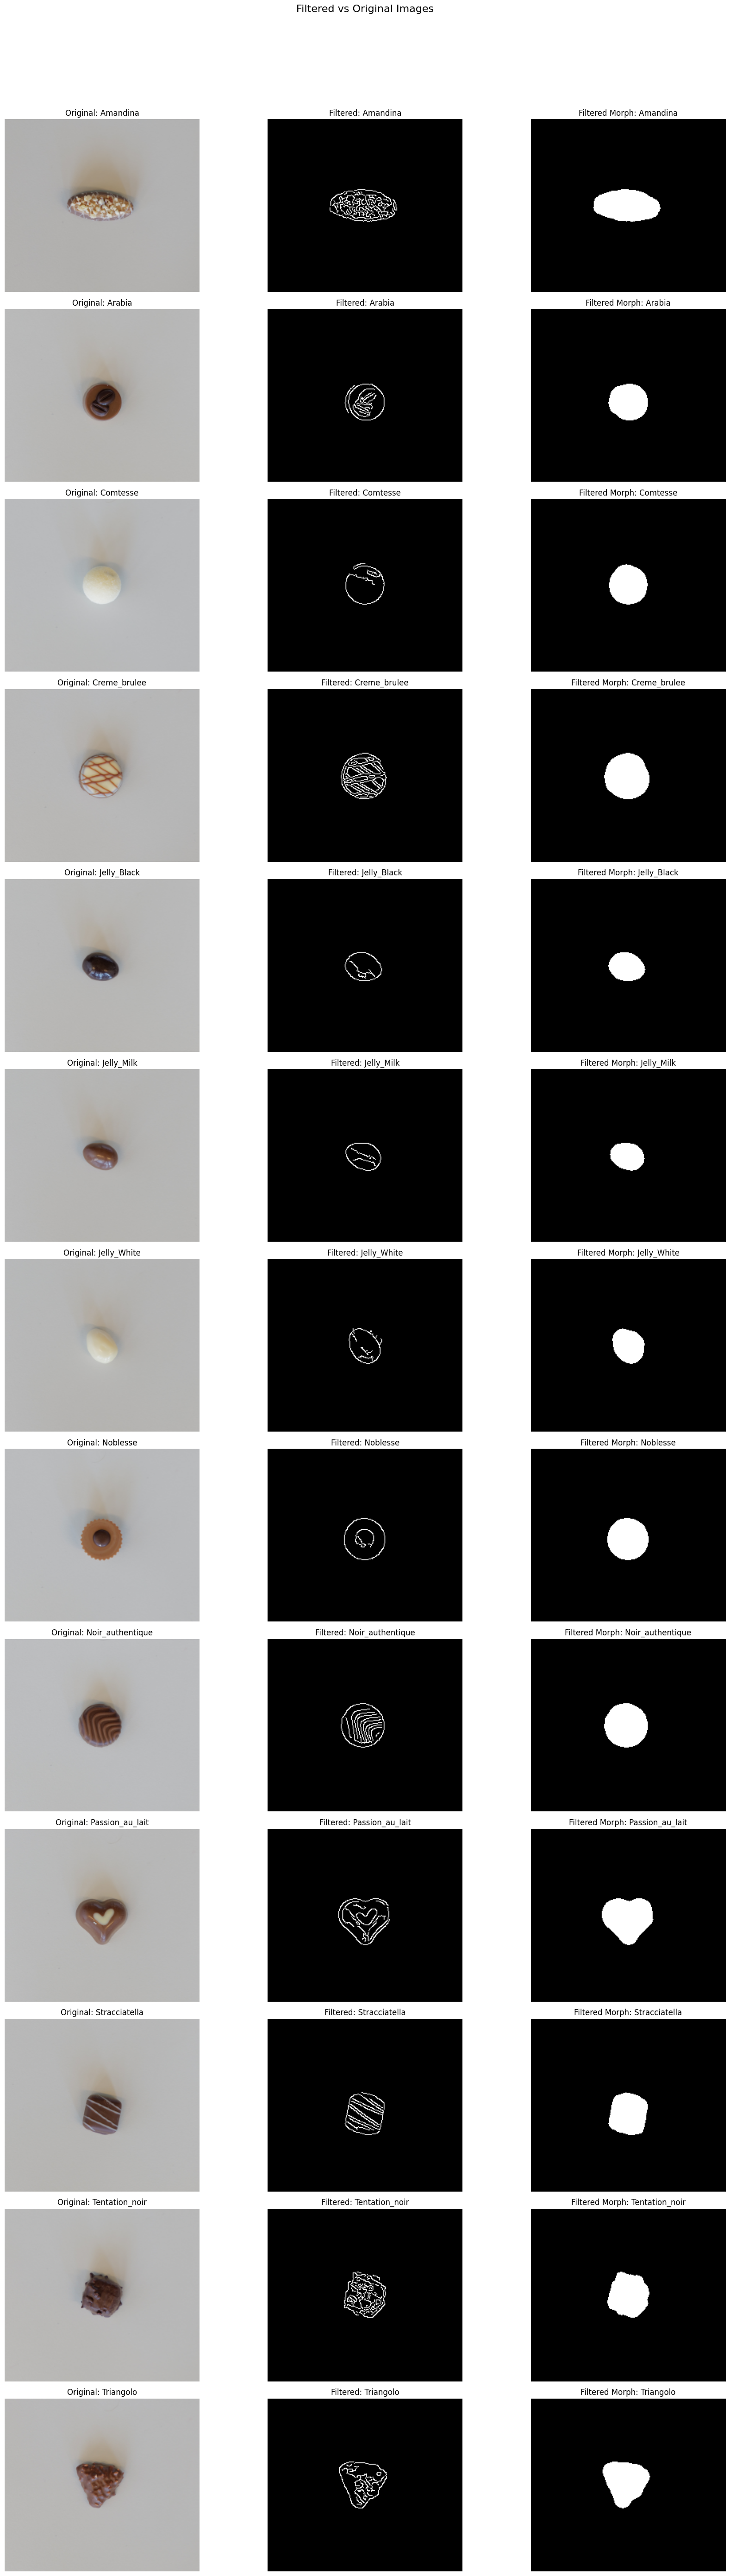

In [189]:
### Make New Dictonary with the cropped reference images and Apply Preprocessing ###

# Define Parameters
t_lower = [30, 30, 10, 30, 30, 30, 10, 30, 30, 30, 30, 10, 30]
t_upper = [115, 115, 120, 115, 115, 115, 80, 115, 115, 115, 115, 90, 115]
aperture_size = 3
L2Gradient = False

# Make the parameters dynamic to tailor the shapes
kernel_size = [6, 10, 16, 10, 12, 14, 12, 16, 4, 8, 6, 5, 8]
min_area_th = 10
min_obj_size = 20
connect = 2

# Dynamic Gaussian Blur 
blur = [5, 3, 3, 3, 9, 7, 1, 7, 5, 3, 5, 1, 5]

# Create a dictionary to store the parameters for each label
reference_parameters = {
    label: {
        "t_lower": t_lower[i],
        "t_upper": t_upper[i],
        "aperture_size": aperture_size,
        "L2Gradient": L2Gradient,
        "kernel_size": kernel_size[i],
        "min_area_th": min_area_th,
        "min_obj_size": min_obj_size,
        "connect": connect,
        "blur": blur[i]
    }
    for i, label in enumerate(reference_labels)
}

# Dynamic Shape Features
features = ["area", "perimeter", "compactness", "rectangularity", "extent"]


# Apply the same preprocessing steps to the cropped images
for key, data in cropped_reference_dict.items():
    # Get the original label for the current image
    original_label = data["original_label"]

    # Retrieve the corresponding parameters from the reference_parameters dictionary
    params = reference_parameters[original_label]

    # Extract the image from the dictionary
    img = data["image"]

    # Extract the RGB channels
    R, G, B = lab1.extract_rgb_channels(img)
    H, S, V = lab1.extract_hsv_channels(img)
    
    # Update the dictionary to include the RGB channels
    data.update({
        "R": R,  # Red channel
        "G": G,  # Green channel
        "B": B,  # Blue channel
        "H": H,  # Hue channel
        "S": S,  # Saturation channel
        "V": V   # Value channel
    })

    # Convert to grayscale
    img_grey = np.uint8(pre.RGB2greyscale(img))
    data["grey"] = img_grey

    # Add a bit of Gaussian blur to the images
    img_blury = cv2.GaussianBlur(img_grey, (params["blur"], params["blur"]), 0)
    data["grey_blur"] = img_blury

    # Apply Canny edge detection
    img_canny = cv2.Canny(img_blury, params["t_lower"], params["t_upper"], apertureSize=params["aperture_size"], L2gradient=params["L2Gradient"])
    data["canny"] = img_canny

    # Apply morphology
    img_morph = lab1.apply_morphology(img_canny, kernel_size=params["kernel_size"], min_area_th=params["min_area_th"], min_obj_size=params["min_obj_size"], connect=params["connect"])
    data["canny_morph"] = img_morph

    # Find contours
    contours = lab2.find_contour(np.expand_dims(img_morph, axis=0))
    data["contours"] = contours
    
    # Compute Shape Features for each contour
    shape_features = [compute_shape_features(c) for c in contours]
    data["shape_features"] = shape_features
    for j, feature in enumerate(features):
        data[feature] = [f[j] for f in shape_features]

    # Add Color Features to the dictionary
    image_size, color_avg, color_isolated_image, cluster_isolated_image, merged_cluster_centers, merged_cluster_labels, coords = find_dominant_chocolate_colors(data["image"], data["canny_morph"])
    first_color_fraction = np.sum(merged_cluster_labels == 0) / len(merged_cluster_labels)

    # Extract primary and secondary colors
    color1 = merged_cluster_centers[0]
    color2 = merged_cluster_centers[1]

    if np.linalg.norm(color1) > np.linalg.norm(color2):
        # Primary color is color1
        data["primary_R"] = int(color1[0])
        data["primary_G"] = int(color1[1])
        data["primary_B"] = int(color1[2])
        data["primary_fraction"] = first_color_fraction

        # Secondary color is color2
        data["secondary_R"] = int(color2[0])
        data["secondary_G"] = int(color2[1])
        data["secondary_B"] = int(color2[2])
        data["secondary_fraction"] = 1 - first_color_fraction
    else:
        # Primary color is color2
        data["primary_R"] = int(color2[0])
        data["primary_G"] = int(color2[1])
        data["primary_B"] = int(color2[2])
        data["primary_fraction"] = 1 - first_color_fraction

        # Secondary color is color1
        data["secondary_R"] = int(color1[0])
        data["secondary_G"] = int(color1[1])
        data["secondary_B"] = int(color1[2])
        data["secondary_fraction"] = first_color_fraction

    # Add average color and isolated images
    data["avg_R"] = color_avg[0]
    data["avg_G"] = color_avg[1]
    data["avg_B"] = color_avg[2]
    data["color_isolated_image"] = color_isolated_image
    data["cluster_isolated_img"] = cluster_isolated_image

    # # Plot the current image pipeline RGB -> Canny -> Morphology
    # plt.figure(figsize=(15, 12))
    # plt.subplot(1, 3, 1)
    # plt.imshow(data["image"])
    # plt.title(f"Original: {original_label}")
    # plt.axis('off')
    # plt.subplot(1, 3, 2)
    # plt.imshow(data["canny"], cmap='gray')
    # plt.title(f"Canny: {original_label}")
    # plt.axis('off')
    # plt.subplot(1, 3, 3)
    # plt.imshow(data["canny_morph"], cmap='gray')
    # plt.title(f"Morphology: {original_label}")
    # plt.axis('off')
    # plt.tight_layout()
    # plt.show()

    # # Print the used parameters
    # print(f"Parameters for {original_label}:")
    # for param, value in params.items():
    #     print(f"  {param}: {value}")
        

pre.plot_ref_images_vs_filtered(cropped_reference_dict, reference_labels)

C:\Users\sunde\AppData\Local\Temp\ipykernel_9612\1666803952.py:17: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


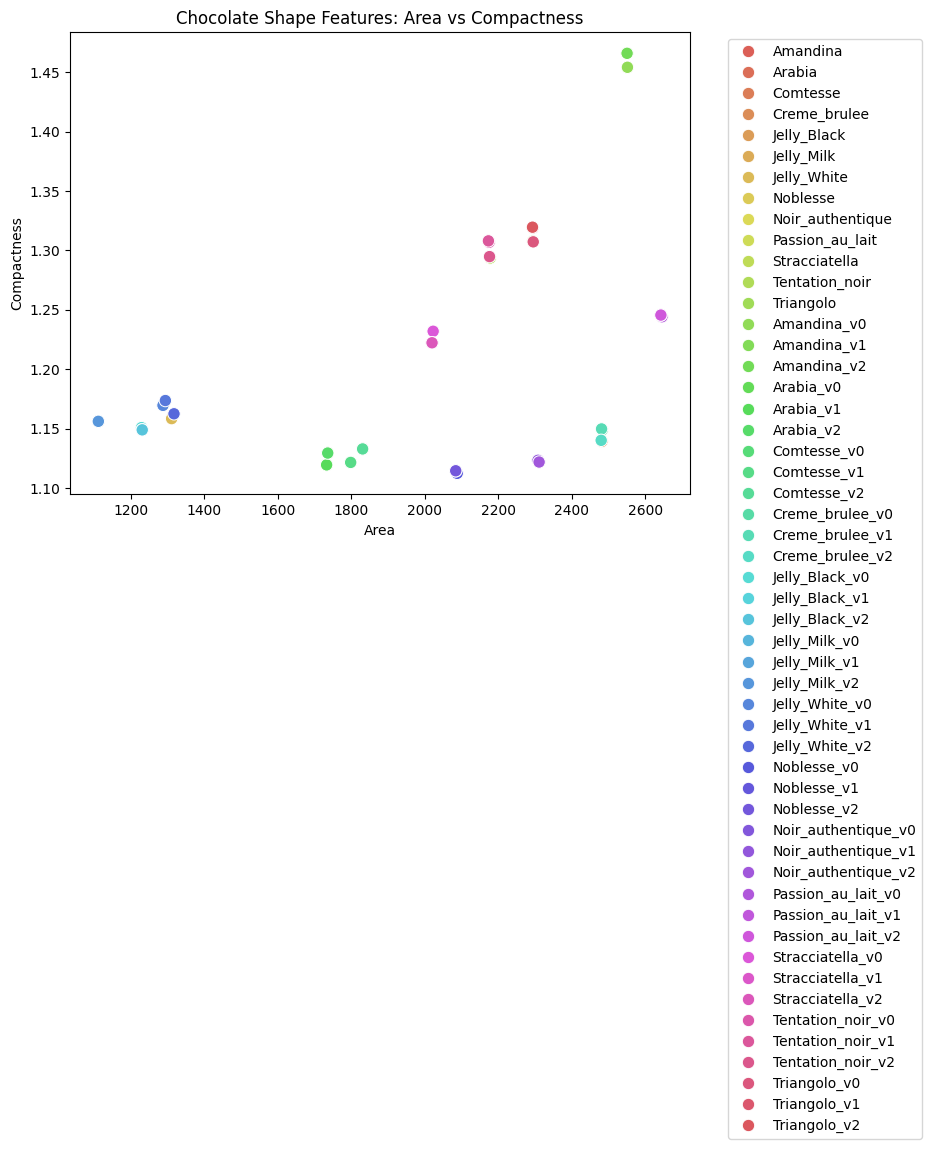

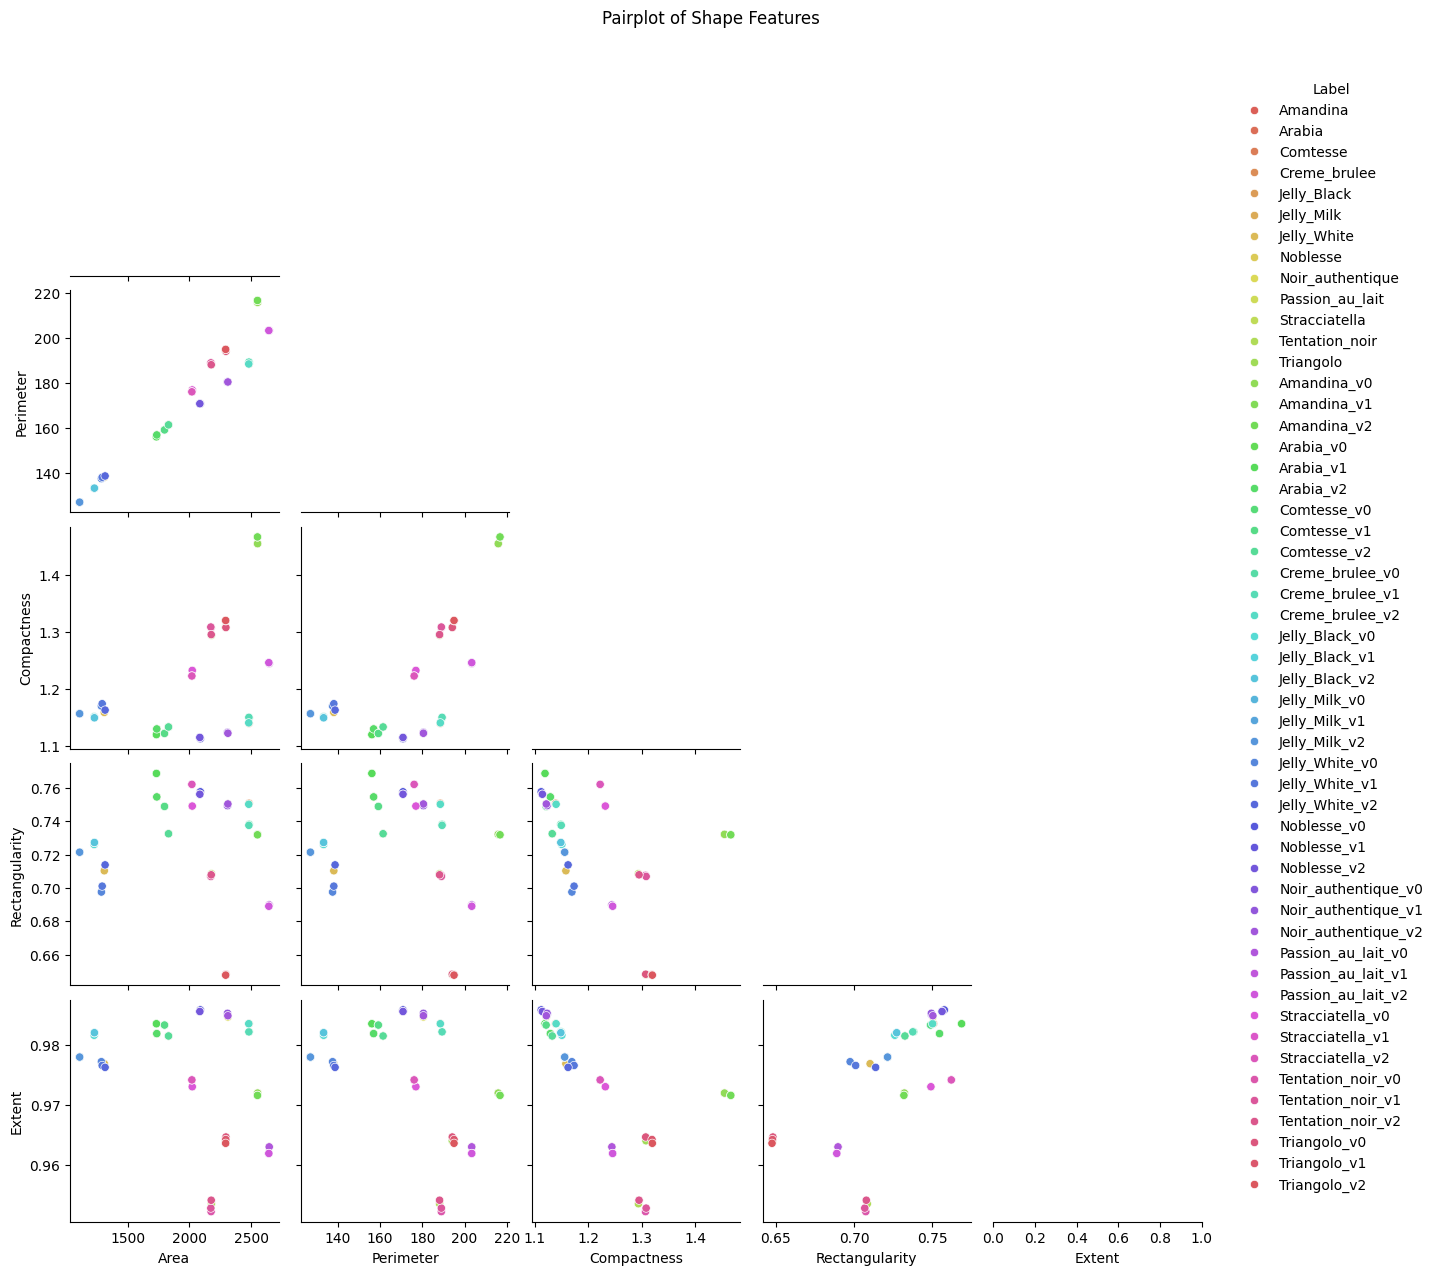

In [ ]:
# Extract Reference Features
reference_features = extract_from_dictionary(cropped_reference_dict, augmented_labels, ["shape_features"])

feature_names = ["Area", "Perimeter", "Compactness", "Rectangularity", "Extent"]
df = pd.DataFrame(reference_features, columns=feature_names)
df['Label'] = augmented_labels

# Create a unique color palette based on number of unique labels
unique_labels = df['Label'].unique()
palette = sns.color_palette("hls", len(unique_labels))  # or try "husl", "Set3", etc.

# 2D scatter plot: Area vs Compactness
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Area", y="Compactness", hue="Label", palette=palette, s=80)
plt.title("Chocolate Shape Features: Area vs Compactness")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Pairplot for all features (optional)
sns.pairplot(df, hue="Label", corner=True, diag_kind="kde", palette=palette)
plt.suptitle("Pairplot of Shape Features", y=1.02)
plt.show()

In [191]:
# ### ---- Confirming That The Dictionary Works ---- ###

# for label in reference_labels:

#     color_avg_R = cropped_reference_dict[label]["avg_R"]
#     color_avg_G = cropped_reference_dict[label]["avg_G"]
#     color_avg_B = cropped_reference_dict[label]["avg_B"]

#     color_primary_R = cropped_reference_dict[label]["primary_R"]
#     color_primary_G = cropped_reference_dict[label]["primary_G"]
#     color_primary_B = cropped_reference_dict[label]["primary_B"]

#     color_secondary_R = cropped_reference_dict[label]["secondary_R"]
#     color_secondary_G = cropped_reference_dict[label]["secondary_G"]
#     color_secondary_B = cropped_reference_dict[label]["secondary_B"]

#     color_primary_fraction = cropped_reference_dict[label]["primary_fraction"]
#     color_secondary_fraction = cropped_reference_dict[label]["secondary_fraction"]

#     print(f"{label} avg color:", color_avg_R, color_avg_G, color_avg_B)
#     print(f"{label} primary color fraction:", color_primary_fraction, f"{label} secondary color fraction:", color_secondary_fraction)
#     print(f"{label} primary color:", color_primary_R, color_primary_G, color_primary_B, f"{label} secondary color:", color_secondary_R, color_secondary_G, color_secondary_B)


# PreProcessing of Training Images #

In [162]:
# Make the reference dictionary a dictionary of dictionaries with initialized values
train_dict = {label: {"image": img} for label, img in zip(train_labels, train_images)}

In [163]:
### EXECUTE PIPELINE ON TRAIN IMAGES ###
t_lower_white = 1
t_upper_white = 70
t_lower_dark = 30
t_upper_dark = 115
aperture_size = 3
L2Gradient = False

# Make the parameters dynamic to tailor the shapes
kernel_size_white = 16
kernel_size_dark = 12
min_area_th = 10
min_obj_size = 20
connect = 2

# Dynamic Gaussian Blur 
blur_white = 1
blur_dark = 5

# Number of images to process
N = N_train


# Apply the same preprocessing steps to the cropped images
for i, imgs in enumerate(train_images[:N]):
    # Extract the RGB channels
    R, G, B = lab1.extract_rgb_channels(imgs)
    H, S, V = lab1.extract_hsv_channels(imgs)
    
    # Update the dictionary to include the RGB and HSV channels
    train_dict[train_labels[i]].update({
        "R": R,  # Red channel
        "G": G,  # Green channel
        "B": B,  # Blue channel
        "H": H,  # Hue channel
        "S": S,  # Saturation channel
        "V": V   # Value channel
    })

    # Convert to grayscale
    img_grey = np.uint8(pre.RGB2greyscale(imgs))
    train_dict[train_labels[i]]["grey"] = img_grey

    # Add a bit of Gaussian blur to the images
    img_blury_white = cv2.GaussianBlur(img_grey, (blur_white, blur_white), 0)
    img_blury_dark = cv2.GaussianBlur(img_grey, (blur_dark, blur_dark), 0)

    # Apply Canny edge detection
    img_canny_white = cv2.Canny(img_blury_white, t_lower_white, t_upper_white, apertureSize=aperture_size, L2gradient=L2Gradient)
    img_canny_dark = cv2.Canny(img_blury_dark, t_lower_dark, t_upper_dark, apertureSize=aperture_size, L2gradient=L2Gradient)

    # Apply morphology
    img_morph_white = lab1.apply_morphology(img_canny_white, kernel_size=kernel_size_white, min_area_th=min_area_th, min_obj_size=min_obj_size, connect=connect)
    img_morph_dark = lab1.apply_morphology(img_canny_dark, kernel_size=kernel_size_dark, min_area_th=min_area_th, min_obj_size=min_obj_size, connect=connect)

    # Update the dictionary with internal `white` and `dark` dictionaries
    train_dict[train_labels[i]]["white"] = {
        "grey_blur": img_blury_white,
        "canny": img_canny_white,
        "canny_morph": img_morph_white
    }

    train_dict[train_labels[i]]["dark"] = {
        "grey_blur": img_blury_dark,
        "canny": img_canny_dark,
        "canny_morph": img_morph_dark
    }


c:\Users\sunde\Desktop\Local_Repos\ImageAnalysisAndPatternRecognitionGroupWork\project\src\lab1.py:275: UserWarning: Any labeled images will be returned as a boolean array. Did you mean to use a boolean array?
  img_morph = remove_small_holes(img_morph, area_threshold=min_area_th, connectivity=connect, out=None)


In [164]:
def plot_train_images_vs_filtered(train_dict, train_labels, pipeline_labels):
    """
    Plot processing pipeline steps for train images with consistent layout.
    
    Args:
        train_dict (dict): Dictionary containing train images and processed versions
        train_labels (list): List of train image labels to display
        pipeline_labels (list): Ordered list of processing steps to show as columns
                               (first should be 'image' for original)
    """
    ncols = len(pipeline_labels)
    nrows = len(train_labels)
    
    # Create figure - width scales with columns, height with rows
    fig, axes = plt.subplots(nrows, ncols, 
                           figsize=(2.5 * ncols, 2.5 * nrows))
    fig.suptitle("Image Processing Pipeline Steps", y=1.02, fontsize=14)
    
    # Handle case when there's only one row
    if nrows == 1:
        axes = axes.reshape(1, -1)
    
    for row_idx, train_label in enumerate(train_labels):
        for col_idx, step_label in enumerate(pipeline_labels):
            ax = axes[row_idx, col_idx]
            
            # Special handling for original image (color)
            if step_label == 'image':
                img = train_dict[train_label].get('image')
                if img is not None:
                    ax.imshow(img)
                ax.set_title(f"Original\n{train_label}", fontsize=10)
            
            # Handling for processed images (grayscale)
            else:
                # Handle nested keys (e.g., 'white/canny')
                keys = step_label.split('/')
                img = train_dict[train_label]
                for key in keys:
                    img = img.get(key, None)
                    if img is None:
                        break
                
                if img is not None:
                    ax.imshow(img, cmap='gray')
                ax.set_title(f"{step_label}", fontsize=10)
            
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()

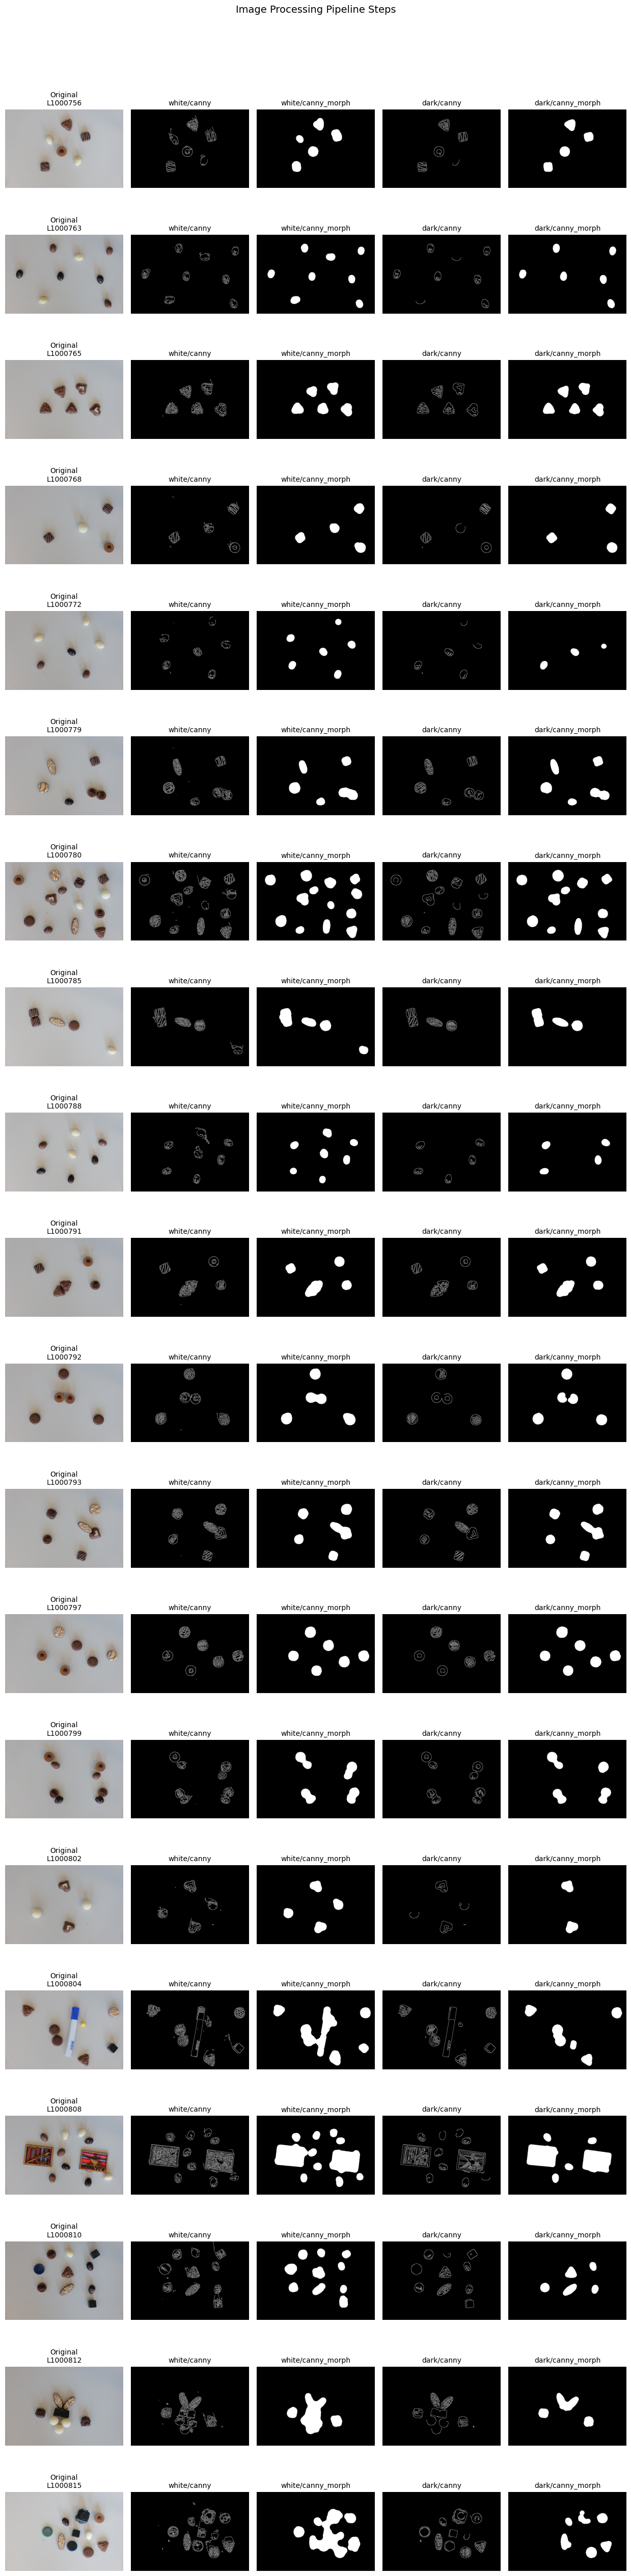

In [165]:
# Define processing steps
processing_steps = [
    'image',               # Column 1
    'white/canny',         # Column 2
    'white/canny_morph',   # Column 3
    'dark/canny',          # Column 4
    'dark/canny_morph'     # Column 5
]


# Call the function
plot_train_images_vs_filtered(
    train_dict=train_dict,
    train_labels=train_labels[:N],
    pipeline_labels=processing_steps
)

In [166]:
### Blob Extraction ###

# For each of the canny_morph train images extract a bounding box of each of the blobs and store 
# binary image within each blob as an array of images in the train_dict under the name "blobs_binary"
# as well as an adjining array of the bounding boxes in the train_dict under the name "blobs_bounding_boxes"
# The bounding boxes are stored as a list of tuples with the coordinates (x, y, w, h) of each blob
# So the bounding boxes can be drawn on the original image

def extract_blobs(canny_morph_image: np.ndarray, plot: bool = False) -> tuple[list[tuple[int, int, int, int]], list[np.ndarray]]:
    """
    Extract blobs from a binary image and return their bounding boxes and binary images.
    
    Args:
        canny_morph_image: Binary image with blobs (2D numpy array).
        plot: Whether to plot the visualization image with bounding boxes and contours.
    
    Returns:
        List of tuples: Each tuple contains (x, y, w, h) of the bounding box for a blob.
        List of binary images: Each binary image corresponds to a blob (as 0/1 or True/False).
    """
    # Find contours
    contours, _ = cv2.findContours(canny_morph_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    bounding_boxes = []
    blobs_binary = []
    
    # Padding for the bounding boxes
    padding = 3

    # Create a copy of the image for visualization
    visualization_image = cv2.cvtColor(canny_morph_image, cv2.COLOR_GRAY2BGR)  # Convert to BGR for color visualization

    for contour in contours:
        if cv2.contourArea(contour) > 0:  # Filter out small areas
            x, y, w, h = cv2.boundingRect(contour)
            bounding_boxes.append((x, y, w, h))
            
            # Create a mask for the blob
            mask = np.zeros_like(canny_morph_image, dtype=np.uint8)
            cv2.drawContours(mask, [contour], -1, 255, -1)  # Fill the contour

            # Extract the blob using the mask
            blob = cv2.bitwise_and(canny_morph_image, canny_morph_image, mask=mask)
            # Crop the blob using the bounding box
            blob_cropped = blob[y - padding:y + h + padding, x - padding:x + w + padding]

            # Normalize the binary output to 0/1
            blob_cropped = (blob_cropped > 0).astype(np.uint8)  # Convert to 0/1 (or use `.astype(bool)` for True/False)
            blobs_binary.append(blob_cropped)

            # Draw the bounding box and contour on the visualization image
            cv2.rectangle(visualization_image, (x - padding, y - padding), (x + w + padding, y + h + padding), (255, 0, 0), 2)
            cv2.drawContours(visualization_image, [contour], -1, (0, 255, 0), 2)

    if plot:
        # Plot the visualization image with bounding boxes and contours
        plt.figure(figsize=(10, 10))
        plt.imshow(cv2.cvtColor(visualization_image, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for plotting
        plt.title("Contours and Bounding Boxes")
        plt.axis('off')
        plt.show()
    
    return bounding_boxes, blobs_binary

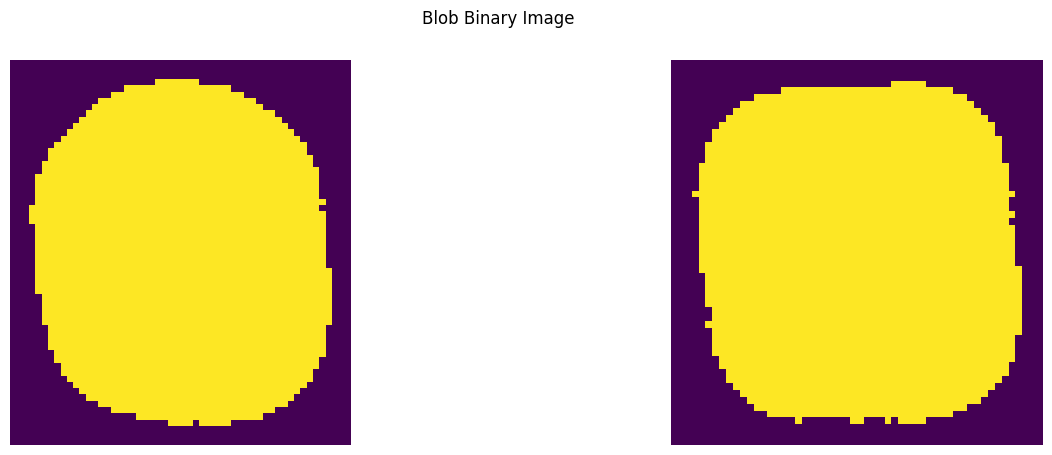

In [167]:
### Apply the blob extraction to the train images ###

for i, dict in enumerate(list(train_dict.values())[:N]):
    # Extract the images from the nested dictionaries
    img_white = dict["white"]["canny_morph"]
    img_dark = dict["dark"]["canny_morph"]

    # Extract blobs from the canny_morph images
    blobs_bounding_boxes_white, blobs_binary_white = extract_blobs(img_white)
    blobs_bounding_boxes_dark, blobs_binary_dark = extract_blobs(img_dark)
    
    # Add the blobs and bounding boxes to the respective nested dictionaries
    dict["white"].update({
        "blobs_bounding_boxes": blobs_bounding_boxes_white,
        "blobs_binary": blobs_binary_white
    })
    dict["dark"].update({
        "blobs_bounding_boxes": blobs_bounding_boxes_dark,
        "blobs_binary": blobs_binary_dark
    })

# Plot a blob from the first image as binary image
label = train_labels[0]
# Compare the original image and the filtered image
pre.compare_2_images(
    image1=train_dict[label]['white']['blobs_binary'][0],
    image2=train_dict[label]['dark']['blobs_binary'][0],
    title="Blob Binary Image")

In [168]:
# # Print number of blobs in each image
# for i, label in enumerate(train_labels[:N]):
#     num_blobs_white = len(train_dict[label]["white"]["blobs_binary"])
#     num_blobs_dark = len(train_dict[label]["dark"]["blobs_binary"])
#     print(f"{label}: {num_blobs_white} blobs (white), {num_blobs_dark} blobs (dark)")
# print(i)

# Find area of each reference blob
areas = []
areas = extract_from_dictionary(cropped_reference_dict, cropped_reference_dict.keys(), ["area"])
print(len(cropped_reference_dict))


def blob_filter(blobs_binary: list[np.ndarray], min_area: int = 0, max_area: int = 100000) -> list[np.ndarray]:
    """
    Filter blobs based on area.
    
    Args:
        blobs_binary: List of binary images representing blobs.
        min_area: Minimum area threshold for a blob to be retained.
        max_area: Maximum area threshold for a blob to be retained.
    
    Returns:
        List of filtered blobs that meet the area criteria.
    """
    filtered_blobs = []
    for blob in blobs_binary:
        area = np.sum(blob > 0)  # Count non-zero pixels (area)
        if min_area <= area <= max_area:
            filtered_blobs.append(blob)
    return filtered_blobs

52


In [169]:
### Extract Prominent Colors From Blob Locations ###

def extract_color_from_blobs(
    img: np.ndarray,
    blobs_bounding_boxes: list[tuple[int, int, int, int]],
    padding: int = 3
) -> list[np.ndarray]:
    """
    Extract cropped color images from the original image using bounding boxes.

    Args:
        img: Original color image (H, W, 3).
        blobs_bounding_boxes: List of (x, y, w, h) tuples.
        padding: Number of pixels to pad around each bounding box.

    Returns:
        List of cropped color images (without any masking).
    """
    color_crops = []
    height, width, _ = img.shape

    for (x, y, w, h) in blobs_bounding_boxes:
        # Apply padding while staying within image bounds
        x1 = max(x - padding, 0)
        y1 = max(y - padding, 0)
        x2 = min(x + w + padding, width)
        y2 = min(y + h + padding, height)

        # Crop the color region
        color_crop = img[y1:y2, x1:x2]
        color_crops.append(color_crop)

    return color_crops



#-------------------------

# Determine how many items to process
max_images = None
labels_to_process = train_labels if max_images is None else train_labels[:max_images]

for label in labels_to_process:
    entry = train_dict[label]
    
    for color_type in ['white', 'dark']:
        
        if color_type not in entry:
            # Skip if this color_type dictionary is missing
            continue
        
        blobs_binary = entry[color_type].get('blobs_binary', [])
        bounding_boxes = entry[color_type].get('blobs_bounding_boxes', [])

        for key in [
                'primary_R', 'primary_G', 'primary_B',
                'secondary_R', 'secondary_G', 'secondary_B',
                'primary_fraction', 'secondary_fraction',
                'avg_R', 'avg_G', 'avg_B',
                'base_img',
                'cluster_isolated_img'
                ]:
                # Create the list if it doesn't exist, else clear it
                if key not in entry[color_type]:
                    entry[color_type][key] = []
                else:
                    entry[color_type][key].clear()
        
        for i, (mask, bbox) in enumerate(zip(blobs_binary, bounding_boxes)):
            #print(f"[{label} - {color_type}] Blob #{i}: bbox={bbox}, mask shape={mask.shape}")
            
            # Place any blob-level processing here
            img = train_dict[label]['image']  # full original color image
            bounding_boxes = train_dict[label][color_type]['blobs_bounding_boxes']
            blobs_binary = train_dict[label][color_type]['blobs_binary']

            # Extract the base image crop around the current blob
            base_image = extract_color_from_blobs(
                img=img,
                blobs_bounding_boxes=[bbox],  # only the current one
                padding=3
            )[0]  # extract_color_from_blobs returns a list, get first item

            # Run KMeans color analysis logic
            image_size, color_avg, color_isolated_image, cluster_isolated_image, merged_cluster_centers, merged_cluster_labels, coords = find_dominant_chocolate_colors(
                base_image,
                blobs_binary[i]
            )

            # Determine primary and secondary colors
            color1 = merged_cluster_centers[0]
            color2 = merged_cluster_centers[1]
            first_color_fraction = np.sum(merged_cluster_labels == 0) / len(merged_cluster_labels)

            if np.linalg.norm(color1) > np.linalg.norm(color2):
                color_primary = color1
                color_secondary = color2
                color_primary_fraction = first_color_fraction
                color_secondary_fraction = 1 - first_color_fraction
            else:
                color_primary = color2
                color_secondary = color1
                color_primary_fraction = 1 - first_color_fraction
                color_secondary_fraction = first_color_fraction

            # Extract RGB values
            color_primary_R, color_primary_G, color_primary_B = map(int, color_primary)
            color_secondary_R, color_secondary_G, color_secondary_B = map(int, color_secondary)
            color_avg_R, color_avg_G, color_avg_B = map(int, color_avg)
            
            """
            # Optional: show comparison plot
            pre.compare_2_images(
                image1=base_image,
                image2=cluster_isolated_image,
                title=f"{label} - {color_type} - Blob #{i}"
            )
            """

            """
            # Debugging prints
            print(f"[{label} - {color_type} - Blob #{i}]")
            print("Primary RGB:", color_primary_R, color_primary_G, color_primary_B)
            print("Secondary RGB:", color_secondary_R, color_secondary_G, color_secondary_B)
            print("Color Avg: ", color_avg_R, color_avg_G, color_avg_B)
            """

            # - training data
            train_dict[label][color_type]['primary_R'].append(int(color_primary[0]))
            train_dict[label][color_type]['primary_G'].append(int(color_primary[1]))
            train_dict[label][color_type]['primary_B'].append(int(color_primary[2]))

            train_dict[label][color_type]['secondary_R'].append(int(color_secondary[0]))
            train_dict[label][color_type]['secondary_G'].append(int(color_secondary[1]))
            train_dict[label][color_type]['secondary_B'].append(int(color_secondary[2]))

            # - not sure if we should include this in training data
            train_dict[label][color_type]['primary_fraction'].append(color_primary_fraction)
            train_dict[label][color_type]['secondary_fraction'].append(color_secondary_fraction)

            train_dict[label][color_type]['avg_R'].append(int(color_avg[0]))
            train_dict[label][color_type]['avg_G'].append(int(color_avg[1]))
            train_dict[label][color_type]['avg_B'].append(int(color_avg[2]))


            # - data for debugging only
            train_dict[label][color_type]['base_img'].append(base_image)
            train_dict[label][color_type]['cluster_isolated_img'].append(cluster_isolated_image)

            
            



In [170]:
# --- VERIFYING THAT THE DICTIONARY DATA WORKS ---

# N = len(train_labels)  # Number of labels to verify, adjust as needed

# for label in train_labels[:N]:
#     for color_type in ['white', 'dark']:
#         if color_type not in train_dict[label]:
#             continue
        
#         num_blobs = len(train_dict[label][color_type]['primary_R'])
#         print(f"Label: {label}, Color type: {color_type}, Number of blobs: {num_blobs}")
        
#         for i in range(num_blobs):
#             print(f"  Blob {i}:")
#             print(f"    Primary RGB:   ({train_dict[label][color_type]['primary_R'][i]}, "
#                   f"{train_dict[label][color_type]['primary_G'][i]}, "
#                   f"{train_dict[label][color_type]['primary_B'][i]})")
#             print(f"    Secondary RGB: ({train_dict[label][color_type]['secondary_R'][i]}, "
#                   f"{train_dict[label][color_type]['secondary_G'][i]}, "
#                   f"{train_dict[label][color_type]['secondary_B'][i]})")
#             print(f"    Primary fraction:   {train_dict[label][color_type]['primary_fraction'][i]:.3f}")
#             print(f"    Secondary fraction: {train_dict[label][color_type]['secondary_fraction'][i]:.3f}")
#             print(f"    Average RGB:   ({train_dict[label][color_type]['avg_R'][i]}, "
#                   f"{train_dict[label][color_type]['avg_G'][i]}, "
#                   f"{train_dict[label][color_type]['avg_B'][i]})")
            
#             # Optional: show images if you want
#             base_image = train_dict[label][color_type]['base_img'][i]
#             cluster_isolated_image = train_dict[label][color_type]['cluster_isolated_img'][i]

#             pre.compare_2_images(
#                 image1=base_image,
#                 image2=cluster_isolated_image,
#                 title=f"{label} - {color_type} - Blob #{i}"
#             )
            
        
#         print()  # Blank line after each color_type

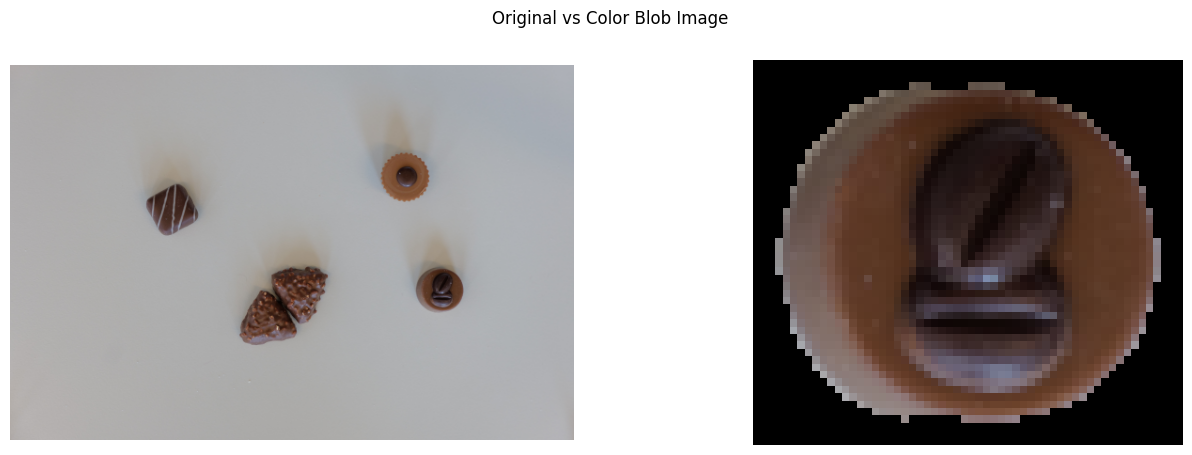

In [171]:
### Extract Color and Greyscale Images from the Blobs ###
# For each of the blobs extract the color image within the blob and store it in the train_dict

# First create a function to extract the color and greyscale images from the blobs

def extract_color_and_greyscale_from_blobs(
    img: np.ndarray,
    blobs_bounding_boxes: list[tuple[int, int, int, int]],
    blobs_binary: list[np.ndarray],
    padding: int = 3
) -> tuple[list[np.ndarray], list[np.ndarray]]:
    """
    Extract color and grayscale images from the blobs in the original image.
    
    Args:
        img: Original image (H,W,3).
        blobs_bounding_boxes: List of tuples with bounding box coordinates (x, y, w, h).
        blobs_binary: List of binary images for each blob.
        padding: Padding to add around the bounding boxes.
    
    Returns:
        List of color images and list of grayscale images for each blob.
    """
    color_images = []
    gray_images = []

    for i, (x, y, w, h) in enumerate(blobs_bounding_boxes):
        # Extract the color image using the bounding box
        color_blob = img[y - padding:y + h + padding, x - padding:x + w + padding]

        # Apply the binary mask to the color image
        mask = blobs_binary[i]
        color_blob = cv2.bitwise_and(color_blob, color_blob, mask=mask)


        color_images.append(color_blob)

        # Convert the color blob to grayscale
        gray_blob = cv2.cvtColor(color_blob, cv2.COLOR_RGB2GRAY)
        gray_images.append(gray_blob)

    return color_images, gray_images

# Now apply the function to the first image in the train_dict
label = train_labels[9]
img = train_dict[label]['image']
blobs_bounding_boxes = train_dict[label]['dark']['blobs_bounding_boxes']
blobs_binary = train_dict[label]['dark']['blobs_binary']
# Extract color and grayscale images from the blobs
color_images, gray_images = extract_color_and_greyscale_from_blobs(
    img=img,
    blobs_bounding_boxes=blobs_bounding_boxes,
    blobs_binary=blobs_binary,
    padding=3
)

# Plot the original image and the first extracted color blob
pre.compare_2_images(
    image1=img,
    image2=color_images[0],
    title="Original vs Color Blob Image"
)


In [172]:
### Add the color and grayscale blobs to the train_dict ###

for i, dict in enumerate(list(train_dict.values())[:N]):
    # Extract the images from the nested dictionaries
    img = dict["image"]
    blobs_bounding_boxes_white = dict["white"]["blobs_bounding_boxes"]
    blobs_binary_white = dict["white"]["blobs_binary"]
    blobs_bounding_boxes_dark = dict["dark"]["blobs_bounding_boxes"]
    blobs_binary_dark = dict["dark"]["blobs_binary"]

    # Extract color and grayscale images from the blobs
    color_images_white, gray_images_white = extract_color_and_greyscale_from_blobs(
        img=img,
        blobs_bounding_boxes=blobs_bounding_boxes_white,
        blobs_binary=blobs_binary_white,
        padding=3
    )
    color_images_dark, gray_images_dark = extract_color_and_greyscale_from_blobs(
        img=img,
        blobs_bounding_boxes=blobs_bounding_boxes_dark,
        blobs_binary=blobs_binary_dark,
        padding=3
    )

    # Add the color and grayscale images to the respective nested dictionaries
    dict["white"].update({
        "color_images_cropped": color_images_white,
        "gray_images_cropped": gray_images_white
    })
    dict["dark"].update({
        "color_images_cropped": color_images_dark,
        "gray_images_cropped": gray_images_dark
    })



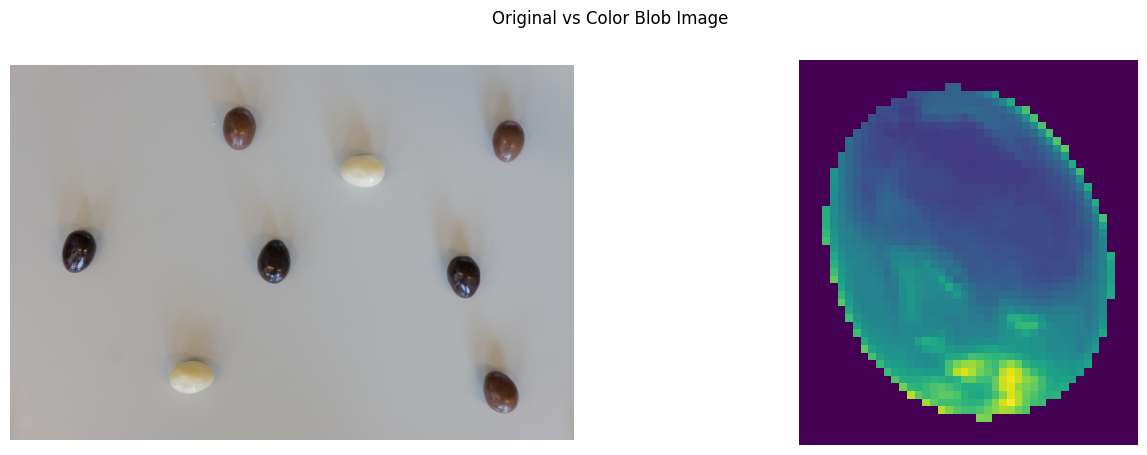

In [173]:
# Plot the first color and grayscale blob from the first image
label = train_labels[1]
# Compare the original image and the color blob
pre.compare_2_images(
    image1=train_dict[label]['image'],
    image2=train_dict[label]['white']['gray_images_cropped'][0],
    title="Original vs Color Blob Image"
)

In [174]:
### Do canny edge detection on the grayscale blobs and Add to the Dictionary ###

# For each of the grayscale blobs apply canny edge detection and store the images in the train_dict
for i, dict in enumerate(list(train_dict.values())[:N]):
    # Extract the images from the nested dictionaries
    gray_images_cropped_white = dict["white"]["gray_images_cropped"]
    gray_images_cropped_dark = dict["dark"]["gray_images_cropped"]

    # Apply Canny edge detection to the grayscale blobs
    canny_blobs_white = []
    canny_blobs_dark = []

    for img in gray_images_cropped_white:
        img_canny = cv2.Canny(img, t_lower_white, t_upper_white, apertureSize=aperture_size, L2gradient=L2Gradient)
        canny_blobs_white.append(img_canny)

    for img in gray_images_cropped_dark:
        img_canny = cv2.Canny(img, t_lower_dark, t_upper_dark, apertureSize=aperture_size, L2gradient=L2Gradient)
        canny_blobs_dark.append(img_canny)

    # Add the canny images to the respective nested dictionaries
    dict["white"].update({
        "canny_cropped": canny_blobs_white
    })
    dict["dark"].update({
        "canny_cropped": canny_blobs_dark
    })



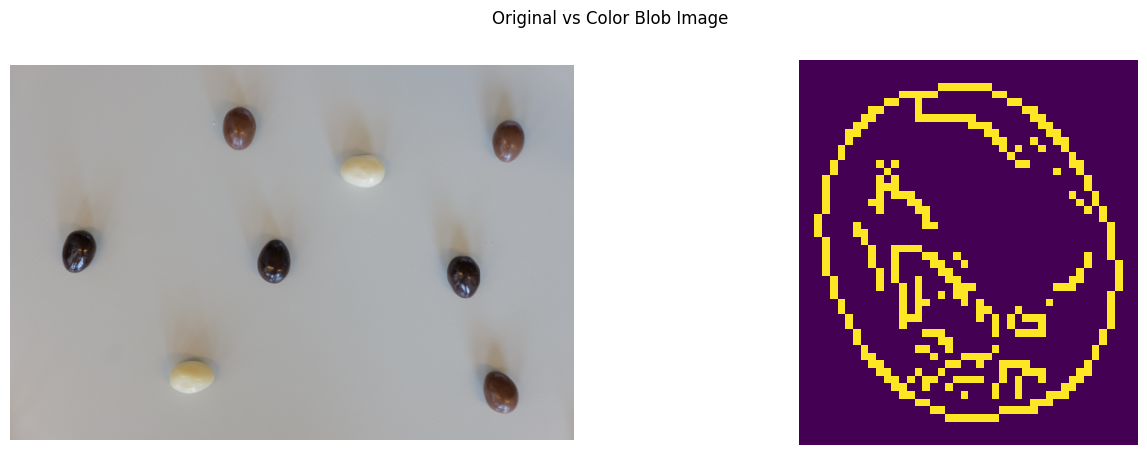

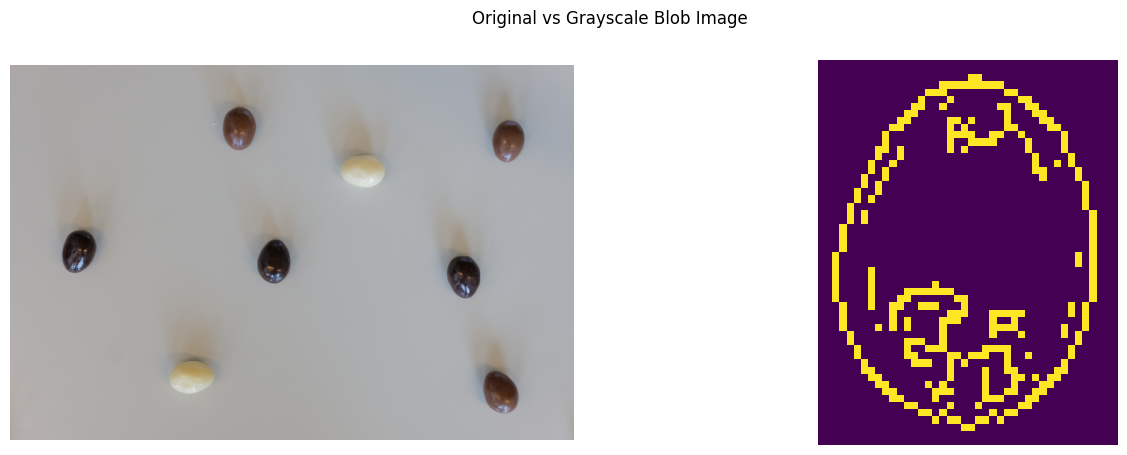

In [175]:
# Plot the first color and canny blob from the first image
label = train_labels[1]
# Compare the original image and the color blob
pre.compare_2_images(
    image1=train_dict[label]['image'],
    image2=train_dict[label]['white']['canny_cropped'][0],
    title="Original vs Color Blob Image"
)
# Compare the original image and the grayscale blob
pre.compare_2_images(
    image1=train_dict[label]['image'],
    image2=train_dict[label]['dark']['canny_cropped'][2],
    title="Original vs Grayscale Blob Image"
)

In [176]:
### Add th contours to the Dictionary ###
# For each of the canny blobs apply contours and store the images in the train_dict
for i, dict in enumerate(list(train_dict.values())[:N]):
    # Extract the images from the nested dictionaries
    blobs_white = dict["white"]["blobs_binary"]
    blobs_dark = dict["dark"]["blobs_binary"]

    # Apply contours to the canny blobs
    contours_blobs_white = []
    contours_blobs_dark = []

    for img in blobs_white:
        img = np.expand_dims(img, axis=0)  # Shape becomes (1, H, W)
        contours = lab2.find_contour(img)  
        contours_blobs_white.append(contours)

    for img in blobs_dark:
        img = np.expand_dims(img, axis=0)  # Shape becomes (1, H, W)
        contours = lab2.find_contour(img)
        contours_blobs_dark.append(contours)

    # Add the contours to the respective nested dictionaries
    dict["white"].update({
        "contours": contours_blobs_white
    })
    dict["dark"].update({
        "contours": contours_blobs_dark
    })

In [177]:
### Add Shape Features to the Dictionary ###
# For each of the contours calculate the shape features and store them in the train_dict
for i, data in enumerate(list(train_dict.values())[:N]):  # Rename 'dict' to 'data' to avoid shadowing the built-in dict type
    # Extract the contours from the nested dictionaries
    contours_blobs_white = data["white"]["contours"]
    contours_blobs_dark = data["dark"]["contours"]

    # Define the shape feature names
    features = ["area", "perimeter", "compactness", "rectangularity", "extent"]

    # Initialize dictionaries to store individual shape features
    shape_features_white = {feature: [] for feature in features}
    shape_features_dark = {feature: [] for feature in features}

    # Initialize arrays to store all shape features
    shape_features_array_white = []
    shape_features_array_dark = []

    # Compute shape features for white contours
    for contour in contours_blobs_white:
        shape_features = compute_shape_features(np.array(contour))  # Compute shape features for the contour
        shape_features_array_white.append(shape_features)  # Store the full array of shape features
        for i, feature in enumerate(features):
            shape_features_white[feature].append(shape_features[i])  # Add the i-th feature to the corresponding list

    # Compute shape features for dark contours
    for contour in contours_blobs_dark:
        shape_features = compute_shape_features(np.array(contour))  # Compute shape features for the contour
        shape_features_array_dark.append(shape_features)  # Store the full array of shape features
        for i, feature in enumerate(features):
            shape_features_dark[feature].append(shape_features[i])  # Add the i-th feature to the corresponding list

    # Add the shape features to the respective nested dictionaries
    data["white"].update(shape_features_white)
    data["white"]["shape_features"] = np.array(shape_features_array_white)  # Store the full array of shape features
    data["dark"].update(shape_features_dark)
    data["dark"]["shape_features"] = np.array(shape_features_array_dark)  # Store the full array of shape features

In [178]:
### Print the Available Data in Train Dict ###
# Print the keys in the train_dict
print('-----Train Dictionary Keys-----')
keys = train_dict.keys()
print(f"Keys in train_dict: {', '.join(keys)}")
keys = train_dict[train_labels[10]].keys()
print(f"Keys in train_dict 1st Layer: {', '.join(keys)}")
keys = train_dict[train_labels[1]]['white'].keys()
print(f"Keys in train_dict 2nd Layer (white): {', '.join(keys)}")

# Print the keys of the reference cropped images dictionary
print('-----Cropped Reference Dictionary Keys-----')
keys = cropped_reference_dict.keys()
print(f"Keys in cropped_reference_dict: {', '.join(keys)}")
keys = cropped_reference_dict[augmented_labels[0]].keys()
print(f"Keys in cropped_reference_dict 1st Layer: {', '.join(keys)}")



-----Train Dictionary Keys-----
Keys in train_dict: L1000756, L1000763, L1000765, L1000768, L1000772, L1000779, L1000780, L1000785, L1000788, L1000791, L1000792, L1000793, L1000797, L1000799, L1000802, L1000804, L1000808, L1000810, L1000812, L1000815, L1000817, L1000826, L1000827, L1000828, L1000831, L1000843, L1000844, L1000850, L1000851, L1000854, L1000859, L1000866, L1000870, L1000872, L1000875, L1000876, L1000880, L1000882, L1000885, L1000888, L1000890, L1000894, L1000896, L1000899, L1000900, L1000903, L1000909, L1000910, L1000914, L1000916, L1000923, L1000926, L1000928, L1000930, L1000932, L1000939, L1000941, L1000946, L1000951, L1000952, L1000957, L1000963, L1000964, L1000965, L1000971, L1000972, L1000974, L1000977, L1000979, L1000981, L1000987, L1000989, L1000992, L1000993, L1001000, L1010004, L1010008, L1010009, L1010012, L1010014, L1010015, L1010019, L1010022, L1010026, L1010029, L1010031, L1010032, L1010035, L1010041, L1010045
Keys in train_dict 1st Layer: image, R, G, B, H, 

In [179]:
print(cropped_reference_dict[augmented_labels[2]].keys())

dict_keys(['image', 'original_label', 'is_augmented', 'rotation', 'R', 'G', 'B', 'H', 'S', 'V', 'grey', 'grey_blur', 'canny', 'canny_morph', 'contours', 'shape_features', 'area', 'perimeter', 'compactness', 'rectangularity', 'extent', 'primary_R', 'primary_G', 'primary_B', 'primary_fraction', 'secondary_R', 'secondary_G', 'secondary_B', 'secondary_fraction', 'avg_R', 'avg_G', 'avg_B', 'color_isolated_image', 'cluster_isolated_img'])


In [180]:
# New dictionary is N entries of train_dict
KNN_train_dict = {}
for i in range(N):
    KNN_train_dict[train_labels[i]] = train_dict[train_labels[i]]

print(N)

20


# KNN Classifier #

In [181]:
class ChocolateClassifier:
    def __init__(self, reference_labels):
        self.reference_labels = reference_labels
        self.feature_options = ['area', 'compactness', 'primary_R', 'primary_G', 'primary_B']
    
    def prepare_data(self, cropped_reference_dict, train_dict, train_image_key, eval_params):
        """Prepare training and test data with selected features"""
        # Validate requested features
        if not all(param in self.feature_options for param in eval_params):
            raise ValueError(f"Invalid feature(s) in eval_params. Options are: {self.feature_options}")
        
        print("\n=== REFERENCE CHOCOLATES FEATURE VALUES ===")
        print(f"{'Chocolate Type':<20}", "\t".join([f"{param:<12}" for param in eval_params]))
        
        # Extract reference features and labels
        X_ref, y_ref = [], []
        for chocolate_type, data in cropped_reference_dict.items():
            # Check if this is an augmented image (has original_label)
            if 'original_label' in data:
                actual_label = data['original_label']
            else:
                actual_label = chocolate_type
                
            # Attempt to format the features
            try:
                # Extract the first value from the list if the feature is a list with length 1
                features = [
                    param[0] if isinstance(param, list) and len(param) == 1 else param
                    for param in [data[param] for param in eval_params]
                ]
                
                print(f"{actual_label:<20}", "\t".join([f"{val:<12.4f}" for val in features]))
                
                X_ref.append(features)
                y_ref.append(actual_label)
            except KeyError as e:
                raise KeyError(f"Missing feature {str(e)} in reference data for {chocolate_type}")
                
        X_test = []
        try:
            train_data = train_dict[train_image_key]['white']
            num_chocolates = len(train_data['area'])
            print("\n=== TRAIN CHOCOLATES FEATURE VALUES ===")
            for i in range(num_chocolates):
                try:
                    features = [train_data[param][i] for param in eval_params]
                    print(f"{f'Choc {i+1}':<12}", "\t".join([f"{val:<12.4f}" for val in features]))
                    
                    X_test.append(features)
                except (KeyError, IndexError) as e:
                    raise KeyError(f"Missing feature {str(e)} in test image {train_image_key}")
        
        except KeyError as e:
            raise KeyError(f"Invalid train image key or missing white chocolates: {str(e)}")
        
        return np.squeeze(np.array(X_ref)), np.squeeze(np.array(y_ref)), np.squeeze(np.array(X_test))
    
    def classify_chocolates(self, cropped_reference_dict, train_dict, train_image_key, 
                          eval_params, n_neighbors=5):
        """Main classification function"""
        # Prepare data
        X_train, y_train, X_test = self.prepare_data(
            cropped_reference_dict, train_dict, train_image_key, eval_params)
        
        # Standardize and classify
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        print("\nClass distribution in y_train:")
        print(Counter(y_train))
        
        knn = KNeighborsClassifier(n_neighbors=n_neighbors)
        knn.fit(X_train_scaled, y_train)
        
        predictions = knn.predict(X_test_scaled)
        probabilities = knn.predict_proba(X_test_scaled)
        print("\nPredictions:", predictions)
        print("Probabilities:", probabilities)

        distances, indices = knn.kneighbors(X_test_scaled)
        print("\nDistances to nearest neighbors:")
        print(distances)
        
        # Count predictions
        counts = defaultdict(int)
        for label in self.reference_labels:
            counts[label] = 0
        for pred in predictions:
            counts[pred] += 1
        
        # Prepare results
        results = {
            'predictions': predictions,
            'probabilities': probabilities,
            'counts': counts,
            'classifier': knn,
            'scaler': scaler
        }
        
        submission = self.print_results(train_image_key, eval_params, results)

        return results, submission
    
    def print_results(self, image_key, eval_params, results):
        """Print formatted results"""
        print(f"\nResults for image {image_key} using features {eval_params}:")
        print("-" * 50)
        print("Chocolate Counts:")
        for label, count in results['counts'].items():
            print(f"{label:<20}: {count}")
        
        print("\nIndividual Predictions:")
        for i, (pred, prob) in enumerate(zip(results['predictions'], results['probabilities'])):
            print(f"Chocolate {i+1:>2}: {pred:<20} (confidence: {max(prob)*100:.1f}%)")

        # Submission Chocolate Order
        proper_order = ['id', 'Jelly_White', 'Jelly_Milk', 'Jelly_Black', 'Amandina', 'Crème_brulée', 
                        'Triangolo', 'Tentation_noir', 'Comtesse', 'Noblesse', 'Noir_authentique', 
                        'Passion_au_lait', 'Arabia', 'Stracciatella']
        
        # Format submission results
        submission = [int(image_key[1:])] + list(results['counts'].values())
        print("\nSubmission Format (Before Reordering):")
        print(submission)

        for label in results['counts']:
            print(label)

        # Reorder the submission array
        reordered_submission = [submission[0]]  # Start with the 'id'
        for label in proper_order[1:]:  # Skip 'id' in proper_order
            if label in results['counts']:
                # print(f"Adding {label} to submission")
                reordered_submission.append(results['counts'][label])
            else:
                # print(f"Label {label} not found in counts, adding 0")
                reordered_submission.append(0)  # Add 0 if the label is missing

        print("\nSubmission Format (After Reordering):")
        print(reordered_submission)
        return reordered_submission

classifier = ChocolateClassifier(reference_labels)
label = train_labels[0]
# Example classification with feature value printing
results, submission = classifier.classify_chocolates(
    cropped_reference_dict=cropped_reference_dict,
    train_dict=train_dict,
    train_image_key=label,  
    eval_params=['area', 'compactness', 'primary_R', 'primary_G', 'primary_B'],  # Features to use
    n_neighbors=3
)

# Plot Train image



=== REFERENCE CHOCOLATES FEATURE VALUES ===
Chocolate Type       area        	compactness 	primary_R   	primary_G   	primary_B   
Amandina             2551.5000   	1.4541      	189.0000    	181.0000    	168.0000    
Arabia               1735.5000   	1.1296      	84.0000     	54.0000     	40.0000     
Comtesse             1830.5000   	1.1330      	218.0000    	217.0000    	208.0000    
Creme_brulee         2482.0000   	1.1393      	181.0000    	164.0000    	138.0000    
Jelly_Black          1228.5000   	1.1509      	82.0000     	80.0000     	95.0000     
Jelly_Milk           1111.0000   	1.1562      	142.0000    	129.0000    	141.0000    
Jelly_White          1310.5000   	1.1585      	211.0000    	209.0000    	193.0000    
Noblesse             2088.0000   	1.1125      	133.0000    	90.0000     	63.0000     
Noir_authentique     2311.0000   	1.1220      	111.0000    	76.0000     	62.0000     
Passion_au_lait      2645.5000   	1.2442      	166.0000    	158.0000    	139.0000    
Stracciat

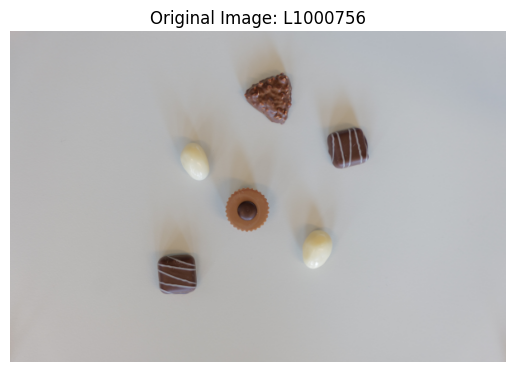

In [182]:
# Show the original image
train_image = train_dict[label]['image']
plt.imshow(train_image)
plt.title(f"Original Image: {label}")
plt.axis('off')
plt.show()

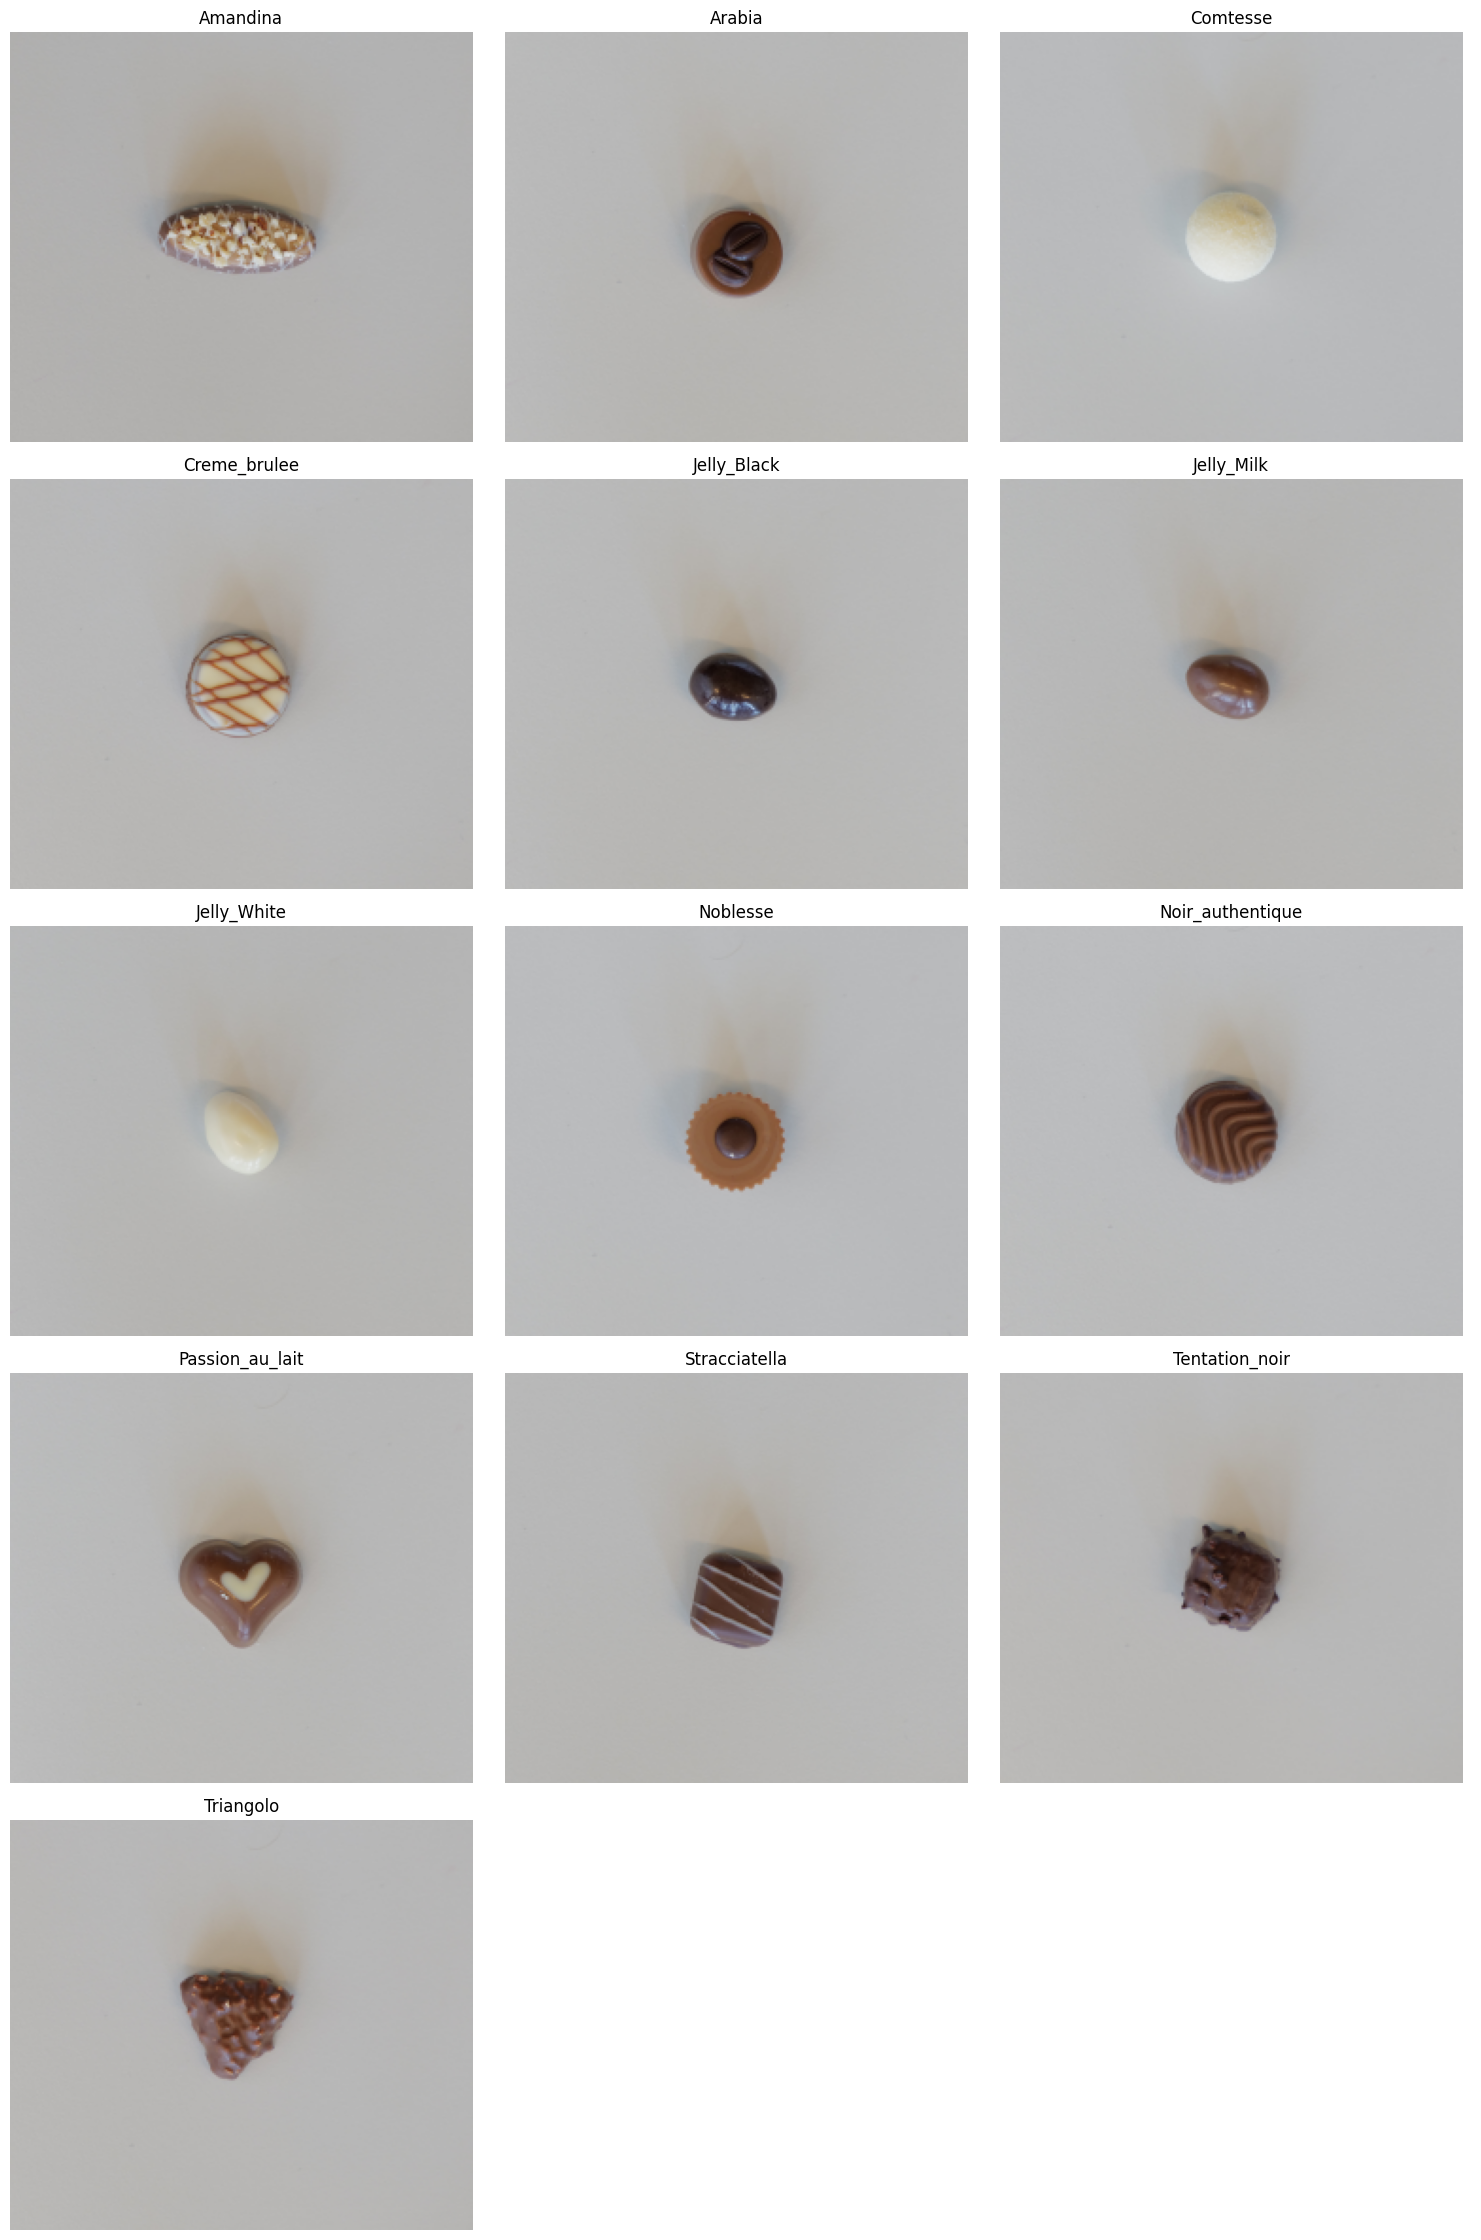

In [183]:
# Show the refrence Images
cropped_reference_images = []
for ref_label in reference_labels:
    if ref_label in cropped_reference_dict:
        cropped_reference_images.append(cropped_reference_dict[ref_label]['image']) 
pre.plot_reference_images(
    images=cropped_reference_images[:13],
    labels=reference_labels
)

In [184]:
### Run the KNN classifier on all of the train images ###

# Create a list to store the submission outputs
submission_outputs = []
# Loop through all the train images
for label in train_labels[:N]:
    # Run the classifier on each image
    results, submission = classifier.classify_chocolates(
        cropped_reference_dict=cropped_reference_dict,
        train_dict=KNN_train_dict,
        train_image_key=label,  # Replace with your image key
        eval_params=['area', 'compactness', 'primary_R', 'primary_G', 'primary_B'],  # Features to use
        n_neighbors=3
    )
    # Append the submission output to the list
    submission_outputs.append(submission)


=== REFERENCE CHOCOLATES FEATURE VALUES ===
Chocolate Type       area        	compactness 	primary_R   	primary_G   	primary_B   
Amandina             2551.5000   	1.4541      	189.0000    	181.0000    	168.0000    
Arabia               1735.5000   	1.1296      	84.0000     	54.0000     	40.0000     
Comtesse             1830.5000   	1.1330      	218.0000    	217.0000    	208.0000    
Creme_brulee         2482.0000   	1.1393      	181.0000    	164.0000    	138.0000    
Jelly_Black          1228.5000   	1.1509      	82.0000     	80.0000     	95.0000     
Jelly_Milk           1111.0000   	1.1562      	142.0000    	129.0000    	141.0000    
Jelly_White          1310.5000   	1.1585      	211.0000    	209.0000    	193.0000    
Noblesse             2088.0000   	1.1125      	133.0000    	90.0000     	63.0000     
Noir_authentique     2311.0000   	1.1220      	111.0000    	76.0000     	62.0000     
Passion_au_lait      2645.5000   	1.2442      	166.0000    	158.0000    	139.0000    
Stracciat

In [185]:
def save_predictions_to_csv(predicted_counts, true_csv_path, output_csv_path):
    """
    Save predicted counts to CSV in same format as ground truth CSV.
    
    Args:
        predicted_counts (numpy.ndarray): Array of predicted counts
        true_csv_path (str): Path to ground truth CSV (for column names)
        output_csv_path (str): Where to save the predictions CSV
    """
    # Load ground truth to get column names
    true_df = pd.read_csv(true_csv_path)

    # Convert predictions to DataFrame
    pred_df = pd.DataFrame(predicted_counts, columns=true_df.columns)  # Exclude 'id' column
    
    # Save to CSV
    pred_df.to_csv(output_csv_path, index=False)
    print(f"Predictions saved to {output_csv_path}")

def analyze_classifier_from_csv(true_csv_path, pred_csv_path, class_names=None):
    """
    Analyze classifier accuracy by comparing two CSV files.
    
    Args:
        true_csv_path (str): Path to ground truth CSV
        pred_csv_path (str): Path to predictions CSV
        class_names (list): Optional list of class names in order
        
    Returns:
        dict: Dictionary containing various accuracy metrics
    """
    # Load both CSVs
    true_df = pd.read_csv(true_csv_path)
    pred_df = pd.read_csv(pred_csv_path)
    
    # Verify they have the same structure
    if not true_df.columns.equals(pred_df.columns):
        raise ValueError("CSV files have different columns")
    if len(true_df) != len(pred_df):
        raise ValueError("CSV files have different numbers of rows")
    if not (true_df['id'] == pred_df['id']).all():
        raise ValueError("Image IDs don't match between files")
    
    # Get class names if not provided
    if class_names is None:
        class_names = true_df.columns[1:].tolist()
    
    # Initialize results dictionary
    results = {
        'per_class_metrics': {},
        'overall_accuracy': None,
        'confusion_matrices': {},
        'absolute_errors': {},
        'example_comparisons': [],
        'per_image_errors': []
    }
    
    # Calculate overall accuracy (exact match of all counts)
    exact_matches = (true_df.iloc[:, 1:] == pred_df.iloc[:, 1:]).all(axis=1).mean()
    results['overall_accuracy'] = exact_matches
    
    # Calculate per-class metrics
    for class_name in class_names:
        true_counts = true_df[class_name]
        pred_counts = pred_df[class_name]
        
        # Absolute errors
        abs_errors = np.abs(true_counts - pred_counts)
        results['absolute_errors'][class_name] = {
            'mean': np.mean(abs_errors),
            'median': np.median(abs_errors),
            'std': np.std(abs_errors),
            'max': np.max(abs_errors)
        }
        
        # Per-image errors
        for img_id, true, pred in zip(true_df['id'], true_counts, pred_counts):
            results['per_image_errors'].append({
                'id': img_id,
                'class': class_name,
                'true': true,
                'pred': pred,
                'error': abs(true - pred)
            })
        
        # Classification metrics (treat as multi-class classification)
        # Flatten all counts to compare each individual prediction
        true_flat = []
        pred_flat = []
        for t, p in zip(true_counts, pred_counts):
            true_flat.extend([class_name] * t)
            pred_flat.extend([class_name] * p)
        
        # Handle case where there are no instances of a class
        if len(true_flat) > 0:
            cm = confusion_matrix(true_flat, pred_flat, labels=class_names)
            results['confusion_matrices'][class_name] = cm
            
            # Calculate precision, recall, f1-score
            report = classification_report(true_flat, pred_flat, 
                                         labels=class_names, 
                                         output_dict=True,
                                         zero_division=0)
            results['per_class_metrics'][class_name] = report[class_name]
    
    # Add some example comparisons
    sample_indices = np.random.choice(len(true_df), min(5, len(true_df)), replace=False)
    for idx in sample_indices:
        true_row = true_df.iloc[idx]
        pred_row = pred_df.iloc[idx]
        example = {
            'id': true_row['id'],
            'true_counts': true_row[1:].to_dict(),
            'predicted_counts': pred_row[1:].to_dict(),
            'total_error': sum(abs(true_row[1:] - pred_row[1:]))
        }
        results['example_comparisons'].append(example)
    
    return results

def plot_confusion_matrix(cm, class_names, title='Confusion Matrix'):
    """Helper function to plot a confusion matrix."""
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', 
                xticklabels=class_names, 
                yticklabels=class_names,
                cmap='Blues')
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

def visualize_results(results, class_names):
    """Visualize the analysis results."""
    # Plot overall accuracy
    print(f"Overall Exact Match Accuracy: {results['overall_accuracy']:.2%}")
    
    # Plot per-class absolute errors
    errors_df = pd.DataFrame(results['absolute_errors']).T
    errors_df[['mean', 'median', 'max']].plot(kind='bar', figsize=(12, 6))
    plt.title('Error Statistics by Chocolate Type')
    plt.ylabel('Count Error')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Plot precision/recall for each class
    metrics_df = pd.DataFrame(results['per_class_metrics']).T
    metrics_df[['precision', 'recall', 'f1-score']].plot(kind='bar', figsize=(12, 6))
    plt.title('Precision, Recall, and F1-Score by Chocolate Type')
    plt.ylabel('Score')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Plot confusion matrix for a sample class
    if results['confusion_matrices']:
        sample_class = np.random.choice(list(results['confusion_matrices'].keys()))
        cm = results['confusion_matrices'][sample_class]
        plot_confusion_matrix(cm, class_names, title=f'Confusion Matrix for {sample_class}')
    
    # Show example comparisons
    print("\nExample Comparisons:")
    for example in results['example_comparisons']:
        print(f"\nImage ID: {example['id']} (Total Error: {example['total_error']})")
        comp_df = pd.DataFrame({
            'True Count': example['true_counts'],
            'Predicted Count': example['predicted_counts'],
            'Error': [abs(t - p) for t, p in zip(
                example['true_counts'].values(),
                example['predicted_counts'].values()
            )]
        })
        print(comp_df)
    
    # Show worst performing images
    per_image_df = pd.DataFrame(results['per_image_errors'])
    worst_images = per_image_df.groupby('id')['error'].sum().sort_values(ascending=False).head(5)
    print("\nImages with Highest Total Errors:")
    print(worst_images)

def calculate_f1_score(true_csv_path, pred_csv_path):
    """
    Calculate the image-wise average F1-score between true and predicted counts
    
    Args:
        true_csv_path: Path to CSV file with true counts
        pred_csv_path: Path to CSV file with predicted counts
        
    Returns:
        Average F1-score across all images
    """
    # Load the CSV files
    true_df = pd.read_csv(true_csv_path)
    pred_df = pd.read_csv(pred_csv_path)
    
    # Ensure the columns are in the same order
    true_df = true_df.sort_values(by='id')
    pred_df = pred_df.sort_values(by='id')
    
    # Get the class names (excluding 'id' column)
    classes = true_df.columns[1:]
    
    # Initialize variables for F1 calculation
    total_f1 = 0
    num_images = len(true_df)
    
    # Calculate F1 for each image
    for i in range(num_images):
        # Get true and predicted counts for this image
        y_true = true_df.iloc[i, 1:].values.astype(int)
        y_pred = pred_df.iloc[i, 1:].values.astype(int)
        
        # Calculate TP and FP+FN
        TP = np.sum(np.minimum(y_true, y_pred))
        FPN = np.sum(np.abs(y_true - y_pred))
        
        # Calculate F1 for this image
        if (2 * TP + FPN) == 0:
            f1 = 0  # handle case where both TP and FPN are 0
        else:
            f1 = (2 * TP) / (2 * TP + FPN)
        
        total_f1 += f1
    
    # Calculate average F1 across all images
    average_f1 = total_f1 / num_images
    
    return average_f1

def evaluate_classifier(true_csv_path, pred_csv_path, visualize=True):
    """
    Comprehensive evaluation of chocolate classifier with metrics and visualizations
    
    Args:
        true_csv_path: Path to CSV file with true counts
        pred_csv_path: Path to CSV file with predicted counts
        visualize: Whether to generate visualizations (default: True)
        
    Returns:
        Dictionary containing all evaluation metrics
    """
    # Load and prepare data
    true_df = pd.read_csv(true_csv_path).sort_values(by='id')
    pred_df = pd.read_csv(pred_csv_path).sort_values(by='id')
    
    # Get class names and ensure matching order
    classes = true_df.columns[1:]
    true_counts = true_df[classes].values
    pred_counts = pred_df[classes].values
    image_ids = true_df['id'].values
    
    # Initialize metrics storage
    metrics = {
        'per_image': [],
        'per_class': {cls: {'TP': 0, 'FP': 0, 'FN': 0} for cls in classes},
        'confusion': np.zeros((len(classes), len(classes)), dtype=int)
    }
    
    # Calculate metrics for each image
    for img_idx in range(len(true_df)):
        y_true = true_counts[img_idx]
        y_pred = pred_counts[img_idx]
        
        # Image-level metrics
        TP = np.sum(np.minimum(y_true, y_pred))
        FPN = np.sum(np.abs(y_true - y_pred))
        f1 = (2 * TP) / (2 * TP + FPN) if (2 * TP + FPN) > 0 else 0
        
        metrics['per_image'].append({
            'image_id': image_ids[img_idx],
            'TP': TP,
            'FPN': FPN,
            'F1': f1,
            'total_true': np.sum(y_true),
            'total_pred': np.sum(y_pred)
        })
        
        # Class-level metrics
        for cls_idx, cls in enumerate(classes):
            diff = y_true[cls_idx] - y_pred[cls_idx]
            metrics['per_class'][cls]['TP'] += min(y_true[cls_idx], y_pred[cls_idx])
            if diff > 0:
                metrics['per_class'][cls]['FN'] += diff
            else:
                metrics['per_class'][cls]['FP'] += abs(diff)
                
        # Confusion matrix (aggregate counts)
        for true_cls_idx in range(len(classes)):
            for pred_cls_idx in range(len(classes)):
                overlap = min(y_true[true_cls_idx], y_pred[pred_cls_idx])
                metrics['confusion'][true_cls_idx, pred_cls_idx] += overlap
    
    # Calculate aggregate metrics
    total_TP = sum(img['TP'] for img in metrics['per_image'])
    total_FPN = sum(img['FPN'] for img in metrics['per_image'])
    avg_f1 = (2 * total_TP) / (2 * total_TP + total_FPN) if (2 * total_TP + total_FPN) > 0 else 0
    
    metrics['overall'] = {
        'average_f1': avg_f1,
        'total_true': np.sum(true_counts),
        'total_pred': np.sum(pred_counts),
        'accuracy': total_TP / np.sum(true_counts) if np.sum(true_counts) > 0 else 0
    }
    
    # Calculate class-level F1 scores
    for cls in classes:
        TP = metrics['per_class'][cls]['TP']
        FP = metrics['per_class'][cls]['FP']
        FN = metrics['per_class'][cls]['FN']
        
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        metrics['per_class'][cls].update({
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'support': np.sum(true_counts[:, classes.get_loc(cls)])
        })
    
    # Generate visualizations if requested
    if visualize:
        generate_visualizations(metrics, classes, image_ids)
    
    return metrics

def generate_visualizations(metrics, classes, image_ids):
    """Generate visualizations for classifier evaluation"""
    plt.figure(figsize=(15, 10))
    
    # 1. Per-image F1 scores
    plt.subplot(2, 2, 1)
    image_f1s = [img['F1'] for img in metrics['per_image']]
    plt.bar(range(len(image_f1s)), image_f1s)
    plt.xticks(range(len(image_f1s)), [str(id) for id in image_ids], rotation=45)
    plt.title('F1 Score per Image')
    plt.xlabel('Image ID')
    plt.ylabel('F1 Score')
    plt.ylim(0, 1)
    
    # 2. Class-level performance
    plt.subplot(2, 2, 2)
    class_f1s = [metrics['per_class'][cls]['f1'] for cls in classes]
    plt.barh(classes, class_f1s)
    plt.title('F1 Score by Chocolate Type')
    plt.xlabel('F1 Score')
    plt.xlim(0, 1)
    
    # 3. Confusion matrix
    plt.subplot(2, 2, 3)
    conf_matrix = metrics['confusion']
    conf_matrix_norm = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]
    sns.heatmap(conf_matrix_norm, annot=True, fmt='.2f', 
                xticklabels=classes, yticklabels=classes,
                cmap='Blues', cbar=False)
    plt.title('Normalized Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    
    # 4. Count comparison
    plt.subplot(2, 2, 4)
    true_totals = [metrics['per_class'][cls]['support'] for cls in classes]
    pred_totals = [metrics['per_class'][cls]['TP'] + metrics['per_class'][cls]['FP'] for cls in classes]
    x = np.arange(len(classes))
    width = 0.35
    plt.bar(x - width/2, true_totals, width, label='True')
    plt.bar(x + width/2, pred_totals, width, label='Predicted')
    plt.xticks(x, classes, rotation=45)
    plt.title('Total Counts by Class')
    plt.ylabel('Count')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print comprehensive report
    print("\n=== COMPREHENSIVE EVALUATION REPORT ===")
    print(f"Overall Average F1-score: {metrics['overall']['average_f1']:.4f}")
    print(f"Total True Chocolates: {metrics['overall']['total_true']}")
    print(f"Total Predicted Chocolates: {metrics['overall']['total_pred']}")
    print(f"Accuracy: {metrics['overall']['accuracy']:.4f}")
    
    print("\n=== PER-CLASS METRICS ===")
    class_report = pd.DataFrame.from_dict(metrics['per_class'], orient='index')
    class_report = class_report[['precision', 'recall', 'f1', 'support']]
    print(class_report.round(4))

# Example usage:
# metrics = evaluate_classifier("true_counts.csv", "predicted_counts.csv")
# The function will display visualizations and print a detailed report

In [186]:
save_predictions_to_csv(
    predicted_counts=submission_outputs,
    true_csv_path='sample_submission.csv',
    output_csv_path='predictions.csv'
)

Predictions saved to predictions.csv


In [187]:
calculate_f1_score(
    true_csv_path="../data/dataset_project_iapr2025/train10images.csv",
    pred_csv_path='predictions.csv'
)

EmptyDataError: No columns to parse from file

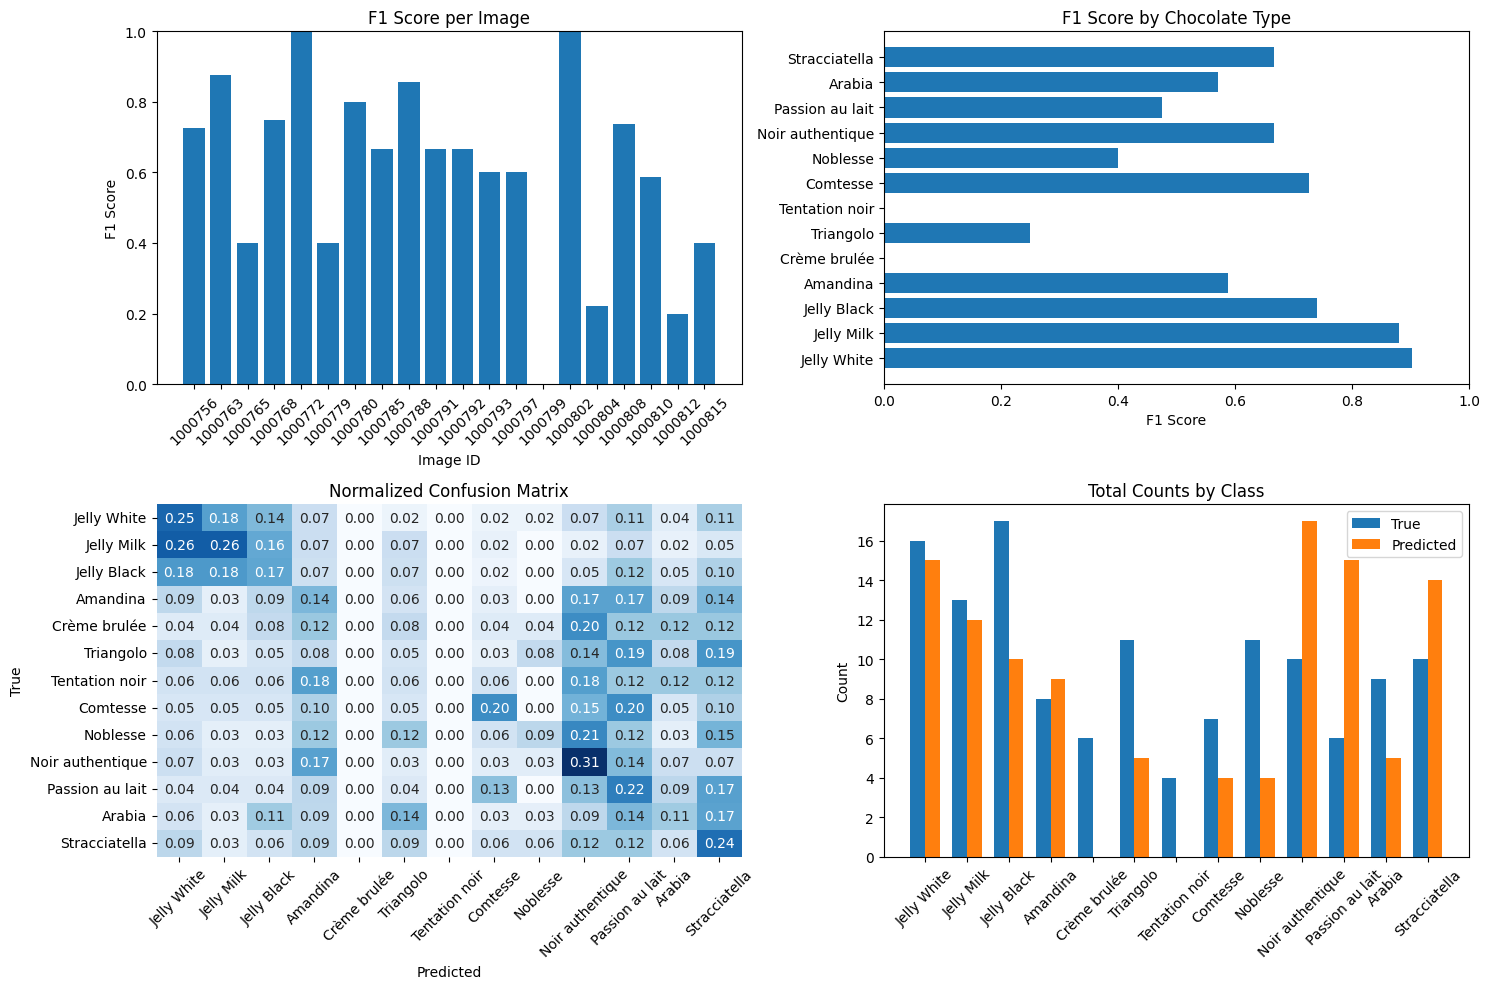


=== COMPREHENSIVE EVALUATION REPORT ===
Overall Average F1-score: 0.6303
Total True Chocolates: 128
Total Predicted Chocolates: 110
Accuracy: 0.5859

=== PER-CLASS METRICS ===
                  precision  recall      f1  support
Jelly White          0.9333  0.8750  0.9032       16
Jelly Milk           0.9167  0.8462  0.8800       13
Jelly Black          1.0000  0.5882  0.7407       17
Amandina             0.5556  0.6250  0.5882        8
Crème brulée         0.0000  0.0000  0.0000        6
Triangolo            0.4000  0.1818  0.2500       11
Tentation noir       0.0000  0.0000  0.0000        4
Comtesse             1.0000  0.5714  0.7273        7
Noblesse             0.7500  0.2727  0.4000       11
Noir authentique     0.5294  0.9000  0.6667       10
Passion au lait      0.3333  0.8333  0.4762        6
Arabia               0.8000  0.4444  0.5714        9
Stracciatella        0.5714  0.8000  0.6667       10


{'per_image': [{'image_id': np.int64(1000756),
   'TP': np.int64(4),
   'FPN': np.int64(3),
   'F1': np.float64(0.7272727272727273),
   'total_true': np.int64(6),
   'total_pred': np.int64(5)},
  {'image_id': np.int64(1000763),
   'TP': np.int64(7),
   'FPN': np.int64(2),
   'F1': np.float64(0.875),
   'total_true': np.int64(8),
   'total_pred': np.int64(8)},
  {'image_id': np.int64(1000765),
   'TP': np.int64(2),
   'FPN': np.int64(6),
   'F1': np.float64(0.4),
   'total_true': np.int64(5),
   'total_pred': np.int64(5)},
  {'image_id': np.int64(1000768),
   'TP': np.int64(3),
   'FPN': np.int64(2),
   'F1': np.float64(0.75),
   'total_true': np.int64(4),
   'total_pred': np.int64(4)},
  {'image_id': np.int64(1000772),
   'TP': np.int64(6),
   'FPN': np.int64(0),
   'F1': np.float64(1.0),
   'total_true': np.int64(6),
   'total_pred': np.int64(6)},
  {'image_id': np.int64(1000779),
   'TP': np.int64(2),
   'FPN': np.int64(6),
   'F1': np.float64(0.4),
   'total_true': np.int64(6),
   '

In [ ]:
evaluate_classifier(
    true_csv_path="../data/dataset_project_iapr2025/train10images.csv",
    pred_csv_path='predictions.csv'
)